### Inciso: Presentación general

# Laboratorio 1 — Series de tiempo de visitantes internacionales

Análisis exploratorio de los ingresos mensuales a Guatemala entre enero de 2009 y junio de 2026. El estudio cubre calidad de datos, comportamiento temporal, composición geográfica, vías y fronteras de ingreso, división cronológica de entrenamiento/prueba y construcción de series mensuales.

In [1]:
# Inciso: Preparación del entorno
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 110
})

RUTA_DATOS = Path("Base_Migracion_2009-2026jun.xlsx")
assert RUTA_DATOS.exists(), f"No se encontró {RUTA_DATOS.resolve()}"

### Inciso: 1 — Preparación de datos

## 1. Carga y preparación

La unidad original es una combinación mensual de atributos migratorios, `Viajero` contiene la cantidad asociada a cada combinación. Se construye una fecha mensual a partir de año y mes y se comprueba la validez de los campos esenciales.

In [2]:
# Inciso: 1 — Preparación de datos
datos_raw = pd.read_excel(RUTA_DATOS, sheet_name="Datos")
notas = pd.read_excel(RUTA_DATOS, sheet_name="Notas")

datos = datos_raw.copy()
datos["Fecha"] = pd.to_datetime(
    dict(year=datos["Año"], month=datos["Mes cod"], day=1),
    errors="coerce"
)
datos = datos.sort_values("Fecha").reset_index(drop=True)

resumen_base = pd.Series({
    "Filas": len(datos),
    "Columnas originales": datos_raw.shape[1],
    "Inicio": datos["Fecha"].min().strftime("%Y-%m"),
    "Fin": datos["Fecha"].max().strftime("%Y-%m"),
    "Meses distintos": datos["Fecha"].nunique(),
    "Total registrado": datos["Viajero"].sum()
}, name="Valor")
display(resumen_base.to_frame())
display(datos.head())

,Valor
Filas,161036
Columnas originales,13
Inicio,2009-01
Fin,2026-06
Meses distintos,210
Total registrado,"52,287,937.09"


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.00,2009-01-01
1,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suecia,EUROPA,Europa,EUROPA DEL NORTE,08 OTROS,Europa,Turista,11.00,2009-01-01
2,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suiza,EUROPA,Europa,EUROPA OCCIDENTAL,08 OTROS,Europa,Turista,7.00,2009-01-01
3,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Trinidad y Tobago,OTROS CARIBEÑOS,América Del Sur y el Caribe,EL CARIBE,08 OTROS,Resto del Mundo,Turista,2.00,2009-01-01
4,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Uruguay,OTROS SUDAMERICANOS,América Del Sur y el Caribe,AMÉRICA DEL SUR,08 OTROS,Suramérica,Turista,1.00,2009-01-01


### Inciso: 1(e) — Criterio de limpieza y comparabilidad

### Criterio de comparabilidad

La categoría `Viajero` cambia de nivel por una reclasificación metodológica a partir de 2023 y `Cruceristas` deja de registrarse en esta fuente desde ese año. Para preservar comparabilidad temporal, las series principales representan visitantes internacionales y suman únicamente `Turista` y `Excursionista`. Esta definición evita interpretar un cambio de medición como un cambio real del turismo.

In [3]:
# Inciso: 1(e) — Criterio de limpieza y comparabilidad
tipos_comparables = ["Turista", "Excursionista"]
visitantes = datos.loc[datos["Tipo de Viajero"].isin(tipos_comparables)].copy()

composicion_tipo = (
    datos.groupby("Tipo de Viajero", as_index=False)["Viajero"]
         .sum()
         .sort_values("Viajero", ascending=False)
)
composicion_tipo["Participación (%)"] = (
    100 * composicion_tipo["Viajero"] / composicion_tipo["Viajero"].sum()
)
display(composicion_tipo)
print(f"Registros usados en las series comparables: {len(visitantes):,}")
print(f"Visitantes acumulados: {visitantes['Viajero'].sum():,.0f}")

,Tipo de Viajero,Viajero,Participación (%)
2,Turista,"37,642,728.55",71.99
1,Excursionista,"9,069,184.34",17.34
3,Viajero,"4,471,622.21",8.55
0,Cruceristas,"1,104,402.00",2.11


Registros usados en las series comparables: 137,642
Visitantes acumulados: 46,711,913


### Inciso: 1(e) — Valores faltantes, duplicados y validaciones

## 2. Calidad de los datos

Se revisan valores faltantes, duplicados exactos, fechas inválidas, cantidades negativas, ceros y continuidad mensual. Los ceros son admisibles en combinaciones de baja frecuencia, mientras que una cantidad negativa no tendría interpretación válida.

In [4]:
# Inciso: 1(e) — Valores faltantes, duplicados y validaciones
faltantes = datos_raw.isna().sum().to_frame("Faltantes")
faltantes["Porcentaje"] = 100 * faltantes["Faltantes"] / len(datos_raw)

meses_esperados = pd.date_range(
    datos["Fecha"].min(), datos["Fecha"].max(), freq="MS"
)
diagnostico = pd.Series({
    "Duplicados exactos": datos_raw.duplicated().sum(),
    "Fechas inválidas": datos["Fecha"].isna().sum(),
    "Cantidades no numéricas": pd.to_numeric(
        datos["Viajero"], errors="coerce"
    ).isna().sum(),
    "Cantidades negativas": (datos["Viajero"] < 0).sum(),
    "Cantidades iguales a cero": (datos["Viajero"] == 0).sum(),
    "Meses esperados": len(meses_esperados),
    "Meses ausentes": len(meses_esperados.difference(datos["Fecha"].unique()))
}, name="Resultado")

display(faltantes)
display(diagnostico.to_frame())

,Faltantes,Porcentaje
Año,0,0.00
Mes cod,0,0.00
Mes,0,0.00
Vía,0,0.00
Frontera,0,0.00
País,0,0.00
Región,0,0.00
Región dos,0,0.00
Regiones OMT,0,0.00
MCEO,0,0.00


,Resultado
Duplicados exactos,0
Fechas inválidas,0
Cantidades no numéricas,0
Cantidades negativas,0
Cantidades iguales a cero,54
Meses esperados,210
Meses ausentes,0


### Inciso: 1(e) — Interpretación de calidad

No se observan faltantes, duplicados exactos, fechas inválidas, cantidades negativas ni huecos mensuales. La cobertura temporal es completa. Los registros con cero se mantienen: representan combinaciones válidas sin flujo observado y eliminarlos sesgaría las agregaciones.

### Inciso: 1(f) — Estadísticas descriptivas

## 3. Estadísticas descriptivas

Las estadísticas se presentan en dos niveles. El nivel fila describe la distribución altamente granular de las combinaciones, el nivel mensual describe la magnitud de la serie agregada y es el adecuado para evaluar el flujo temporal.

In [5]:
# Inciso: 1(f) — Estadísticas descriptivas
serie_mensual = (
    visitantes.groupby("Fecha")["Viajero"]
              .sum()
              .reindex(meses_esperados, fill_value=0)
)
serie_mensual.index.name = "Fecha"
serie_mensual.name = "Visitantes"

descriptivas = pd.concat(
    [
        visitantes["Viajero"].describe().rename("Registro individual"),
        serie_mensual.describe().rename("Total mensual")
    ],
    axis=1
)
display(descriptivas)

print(
    f"Coeficiente de variación mensual: "
    f"{serie_mensual.std() / serie_mensual.mean():.2%}"
)

,Registro individual,Total mensual
count,"137,642.00",210.00
mean,339.37,"222,437.68"
std,"2,515.14","84,724.94"
min,0.00,"9,779.00"
25%,2.00,"170,714.48"
50%,7.00,"227,605.66"
75%,37.00,"278,341.21"
max,"83,511.00","449,114.07"


Coeficiente de variación mensual: 38.09%


### Inciso: 1(f) — Interpretación descriptiva

La media por registro es mucho menor que el total mensual porque la base está en formato largo. La dispersión mensual es elevada y está influida por crecimiento, estacionalidad, el choque de 2020 y la recuperación posterior, por ello no debe interpretarse como variación aleatoria alrededor de un nivel constante.

### Inciso: 1(a) y 1(f) — Comportamiento temporal

## 4. Comportamiento temporal

La media móvil de 12 meses reduce la estacionalidad y permite observar con mayor claridad los cambios de nivel de largo plazo.

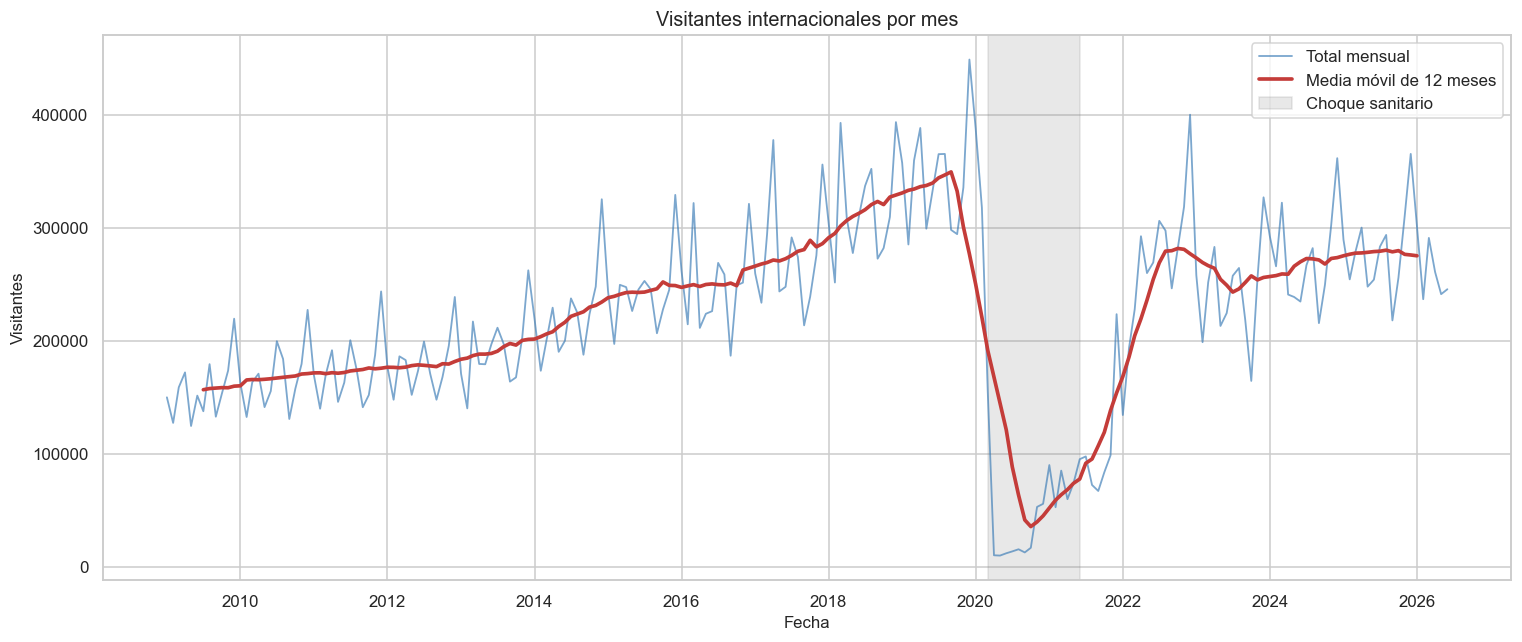

In [6]:
# Inciso: 1(a) y 1(f) — Comportamiento temporal
media_movil = serie_mensual.rolling(12, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(serie_mensual, color="#3679B5", alpha=0.65, lw=1.2, label="Total mensual")
ax.plot(media_movil, color="#C43C39", lw=2.4, label="Media móvil de 12 meses")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
           color="gray", alpha=0.18, label="Choque sanitario")
ax.set(
    title="Visitantes internacionales por mes",
    xlabel="Fecha",
    ylabel="Visitantes"
)
ax.legend()
plt.tight_layout()
plt.show()

### Inciso: 1(a) — Interpretación temporal

Antes de 2020 se aprecia una trayectoria creciente con oscilaciones anuales. El colapso iniciado en marzo de 2020 rompe abruptamente el nivel y domina la variabilidad histórica. La recuperación posterior es clara, aunque la comparación debe considerar que 2026 solo contiene seis meses.

,Visitantes,Variación anual (%),Índice 2019=100
Año,,,
2009,"1,880,182.85",NaN,45.50
2010,"2,004,784.00",6.63,48.52
2011,"2,079,714.60",3.74,50.33
2012,"2,139,541.48",2.88,51.78
2013,"2,289,702.75",7.02,55.41
2014,"2,660,177.32",16.18,64.38
2015,"2,917,886.04",9.69,70.61
2016,"2,997,026.74",2.71,72.53
2017,"3,307,651.29",10.36,80.04


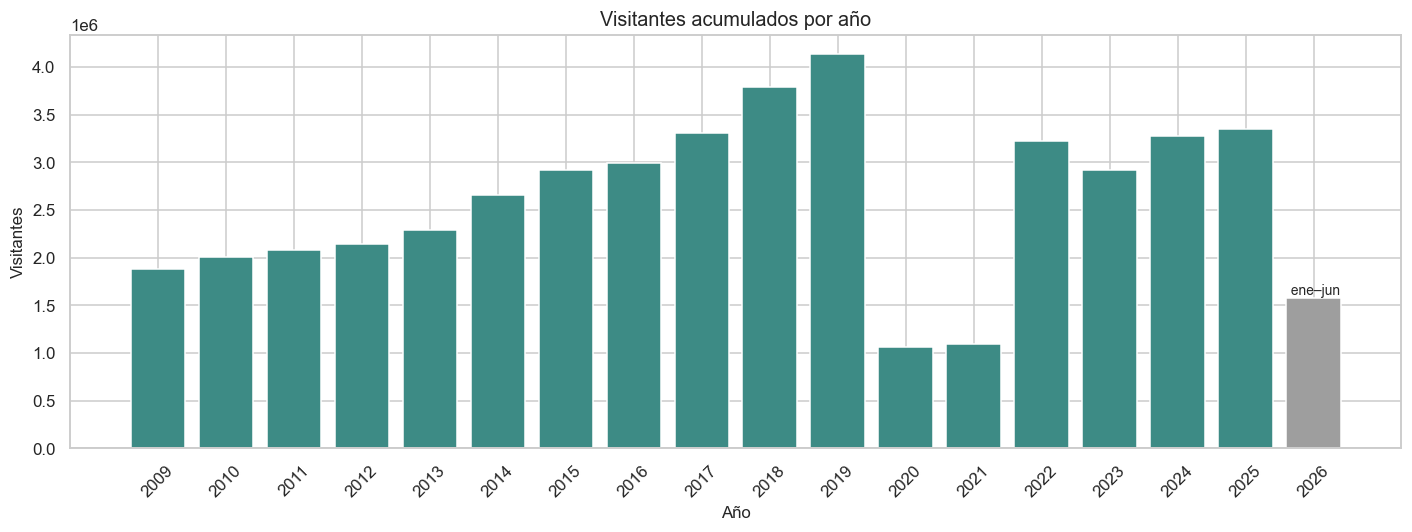

In [7]:
# Inciso: 1(a) y 1(f) — Comparación anual
anual = visitantes.groupby("Año")["Viajero"].sum()
comparacion_anual = anual.to_frame("Visitantes")
comparacion_anual["Variación anual (%)"] = anual.pct_change() * 100
comparacion_anual["Índice 2019=100"] = 100 * anual / anual.loc[2019]
display(comparacion_anual)

colores = np.where(anual.index == 2026, "#9E9E9E", "#3D8B85")
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(anual.index.astype(str), anual.values, color=colores)
ax.set(
    title="Visitantes acumulados por año",
    xlabel="Año",
    ylabel="Visitantes"
)
ax.tick_params(axis="x", rotation=45)
ax.text(
    len(anual) - 1, anual.iloc[-1], " ene–jun",
    ha="center", va="bottom", fontsize=9
)
plt.tight_layout()
plt.show()

### Inciso: 1(a) — Interpretación anual

La comparación anual cuantifica el impacto de 2020 y la recuperación. El índice con base 2019 evita confundir crecimiento porcentual desde un piso muy bajo con recuperación completa. El total de 2026 no es comparable con años completos.

### Inciso: 1(b) y 1(c) — Países y regiones principales

## 5. Países y regiones con mayor volumen

Los rankings se calculan con el acumulado de todo el período. La columna `País` pasa de países individuales a agrupaciones de mercado desde 2023, por ello sirve para describir concentración acumulada, pero las categorías pequeñas no deben interpretarse como series homogéneas durante los 210 meses.

,País,Viajero,Participación (%)
58,El Salvador,"14,079,135.77",30.14
84,Guatemala,"13,870,391.35",29.69
65,Estados Unidos de América,"6,965,679.71",14.91
91,Honduras,"2,520,974.31",5.40
143,México,"1,678,422.55",3.59
20,Belice,"916,101.07",1.96
48,Costa Rica,"860,240.69",1.84
148,Nicaragua,"811,145.39",1.74
45,Colombia,"549,494.69",1.18
38,Canadá,"516,707.89",1.11


,Región dos,Viajero,Participación (%)
1,América Del Centro,"33,283,931.98",71.25
2,América Del Norte,"9,160,810.15",19.61
5,Europa,"2,149,271.06",4.60
3,América Del Sur y el Caribe,"1,413,590.32",3.03
4,Asia,"410,333.51",0.88
6,Oceanía,"135,505.37",0.29
7,Oriente Medio,"133,735.19",0.29
8,Otros Paises Del Mundo,"23,914.30",0.05
0,0,821.00,0.00


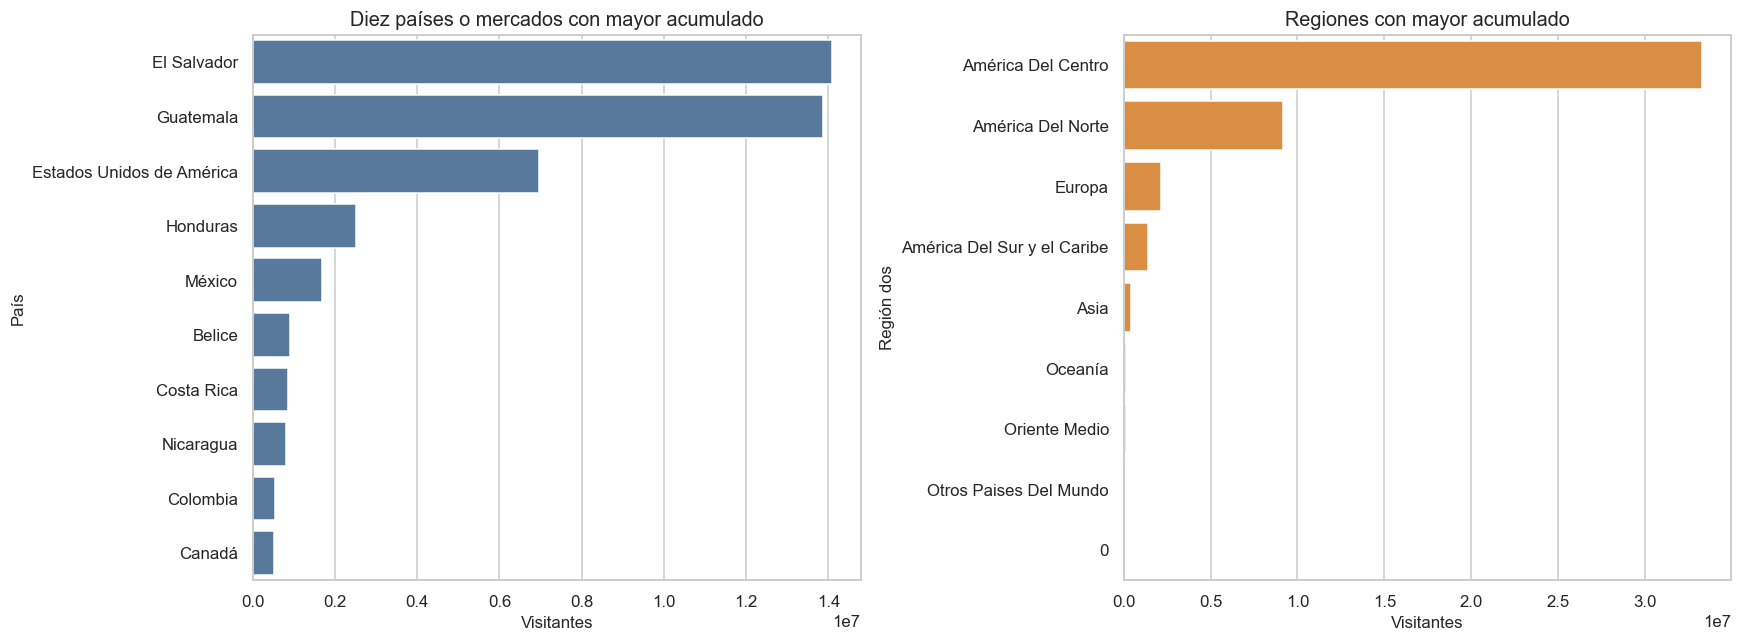

In [8]:
# Inciso: 1(b), 1(c) y 1(f) — Rankings y visualizaciones
def tabla_top(data, categoria, n=10):
    salida = (
        data.groupby(categoria, as_index=False)["Viajero"]
            .sum()
            .sort_values("Viajero", ascending=False)
            .head(n)
            .copy()
    )
    salida["Participación (%)"] = (
        100 * salida["Viajero"] / data["Viajero"].sum()
    )
    return salida

top_paises = tabla_top(visitantes, "País", 10)
top_regiones = tabla_top(visitantes, "Región dos", 10)
display(top_paises)
display(top_regiones)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=top_paises, y="País", x="Viajero",
    color="#4C78A8", ax=axes[0]
)
sns.barplot(
    data=top_regiones, y="Región dos", x="Viajero",
    color="#F28E2B", ax=axes[1]
)
axes[0].set_title("Diez países o mercados con mayor acumulado")
axes[1].set_title("Regiones con mayor acumulado")
axes[0].set_xlabel("Visitantes")
axes[1].set_xlabel("Visitantes")
plt.tight_layout()
plt.show()

### Inciso: 1(b) y 1(c) — Interpretación geográfica

El flujo está fuertemente concentrado en mercados cercanos y en Norteamérica. `América Del Centro` domina el acumulado regional, lo que anticipa la importancia de los pasos terrestres. La aparición de Guatemala como residencia es posible en movimientos de residentes que ingresan al país y debe distinguirse de la nacionalidad.

### Inciso: 1(d) — Vías y fronteras

## 6. Vías y fronteras de ingreso

Se compara la participación de las tres vías y se identifican las fronteras con mayor acumulado. Las fronteras representan puntos de control específicos, por eso su concentración complementa la lectura por vía.

,Vía,Viajero,Participación (%)
2,Terrestre,"27,592,253.33",59.07
0,Aérea,"19,019,418.55",40.72
1,Marítima,"100,241.00",0.21


,Frontera,Viajero,Participación (%)
0,01 La Aurora,"18,989,984.61",40.65
6,07 Valle Nuevo,"10,143,045.32",21.71
8,09 San Cristóbal,"4,183,631.71",8.96
7,08 Pedro de Alvarado,"3,764,229.26",8.06
9,10 La Ermita (Nueva Anguiatú),"2,587,072.27",5.54
19,20 Melchor de Mencos,"1,782,864.39",3.82
12,13 El Cinchado / El Corinto,"1,213,485.14",2.60
10,11 Agua Caliente,"922,419.53",1.97
11,12 El Florido,"910,373.47",1.95
14,15 El Carmen,"852,663.13",1.83


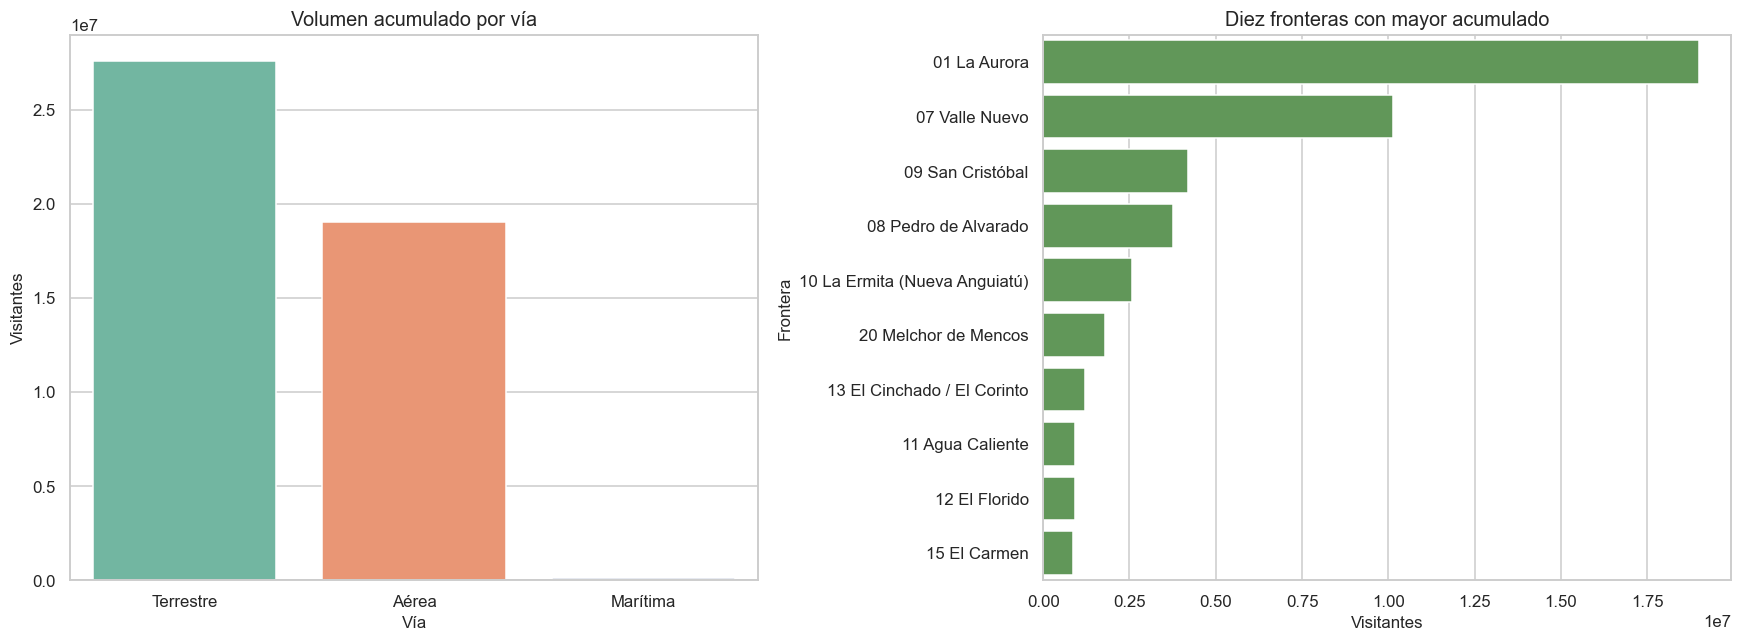

In [9]:
# Inciso: 1(d) y 1(f) — Rankings y visualizaciones
top_vias = tabla_top(visitantes, "Vía", 10)
top_fronteras = tabla_top(visitantes, "Frontera", 10)
display(top_vias)
display(top_fronteras)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=top_vias, x="Vía", y="Viajero",
    hue="Vía", legend=False, palette="Set2", ax=axes[0]
)
sns.barplot(
    data=top_fronteras, y="Frontera", x="Viajero",
    color="#59A14F", ax=axes[1]
)
axes[0].set_title("Volumen acumulado por vía")
axes[1].set_title("Diez fronteras con mayor acumulado")
axes[0].set_ylabel("Visitantes")
axes[1].set_xlabel("Visitantes")
plt.tight_layout()
plt.show()

### Inciso: 1(d) — Interpretación de vías y fronteras

Las vías terrestre y aérea explican prácticamente todo el flujo comparable. La Aurora encabeza los puntos de ingreso por concentrar el tráfico aéreo, mientras que varios pasos terrestres acumulan volúmenes altos asociados a los mercados centroamericanos. La vía marítima requiere cautela porque perdió detalle desde 2017.

### Inciso: 1(c) y 1(d) — Cruce entre región y vía

## 7. Cruce entre región y vía

El cruce muestra la distribución porcentual de cada región entre vías. Se normaliza por fila para evitar que el gran tamaño de una región oculte su patrón de acceso.

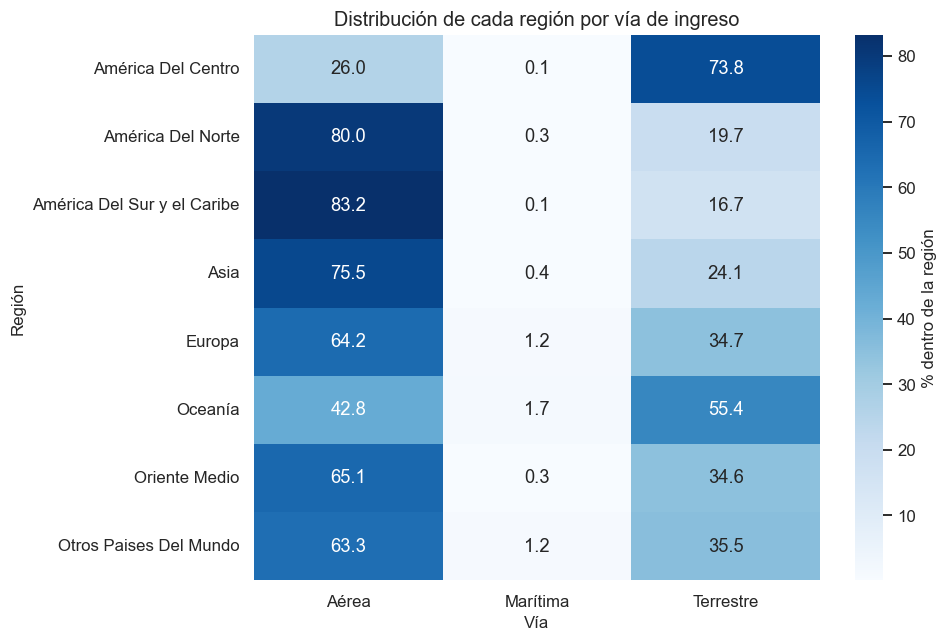

Vía,Aérea,Marítima,Terrestre
Región dos,,,
América Del Centro,26.02,0.13,73.84
América Del Norte,80.02,0.28,19.70
América Del Sur y el Caribe,83.24,0.11,16.65
Asia,75.52,0.37,24.10
Europa,64.19,1.15,34.66
Oceanía,42.84,1.72,55.44
Oriente Medio,65.06,0.30,34.64
Otros Paises Del Mundo,63.25,1.23,35.52


In [10]:
# Inciso: 1(c), 1(d) y 1(f) — Cruce y visualización
regiones_principales = top_regiones["Región dos"].head(8)
cruce = pd.pivot_table(
    visitantes.loc[visitantes["Región dos"].isin(regiones_principales)],
    index="Región dos",
    columns="Vía",
    values="Viajero",
    aggfunc="sum",
    fill_value=0
)
cruce_pct = cruce.div(cruce.sum(axis=1), axis=0) * 100

plt.figure(figsize=(9, 6))
sns.heatmap(
    cruce_pct, annot=True, fmt=".1f", cmap="Blues",
    cbar_kws={"label": "% dentro de la región"}
)
plt.title("Distribución de cada región por vía de ingreso")
plt.xlabel("Vía")
plt.ylabel("Región")
plt.tight_layout()
plt.show()
display(cruce_pct)

### Inciso: 1(c) y 1(d) — Interpretación del cruce

La composición confirma dos patrones distintos: Centroamérica depende principalmente de accesos terrestres, mientras que los mercados más distantes se concentran en la vía aérea. Esta diferencia implica que choques operativos o políticas aplicadas a una vía afectan de manera desigual a las regiones de origen.

### Inciso: 1(e) — Valores atípicos

## 8. Valores atípicos

El criterio IQR se aplica tanto al nivel fila como al total mensual. Una observación extrema no se elimina automáticamente: en una base agregada puede corresponder a una combinación legítima de alto volumen, a un mes estacionalmente fuerte o a un cambio estructural.

,Valor
Límite superior por registro,89.50
Registros marcados por IQR,"22,887.00"
Porcentaje de registros marcados,16.63
Límite superior mensual,"439,781.31"
Meses marcados por IQR,1.00


,Visitantes
Fecha,
2019-12-01,"449,114.07"


,Fecha,Vía,Frontera,País,Región dos,Tipo de Viajero,Viajero
125467,2019-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"83,511.00"
113803,2018-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"81,030.06"
143830,2022-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"76,588.00"
101676,2017-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"72,545.00"
158529,2025-12-01,Terrestre,07 Valle Nuevo,El Salvador,América Del Centro,Turista,"69,806.00"
124479,2019-11-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"68,877.00"
153378,2024-12-01,Terrestre,07 Valle Nuevo,El Salvador,América Del Centro,Turista,"68,085.77"
158552,2025-12-01,Aérea,01 La Aurora,Estados Unidos de América,América Del Norte,Turista,"67,952.00"
77647,2015-12-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"67,786.00"
112766,2018-11-01,Aérea,01 La Aurora,Guatemala,América Del Centro,Turista,"66,196.24"


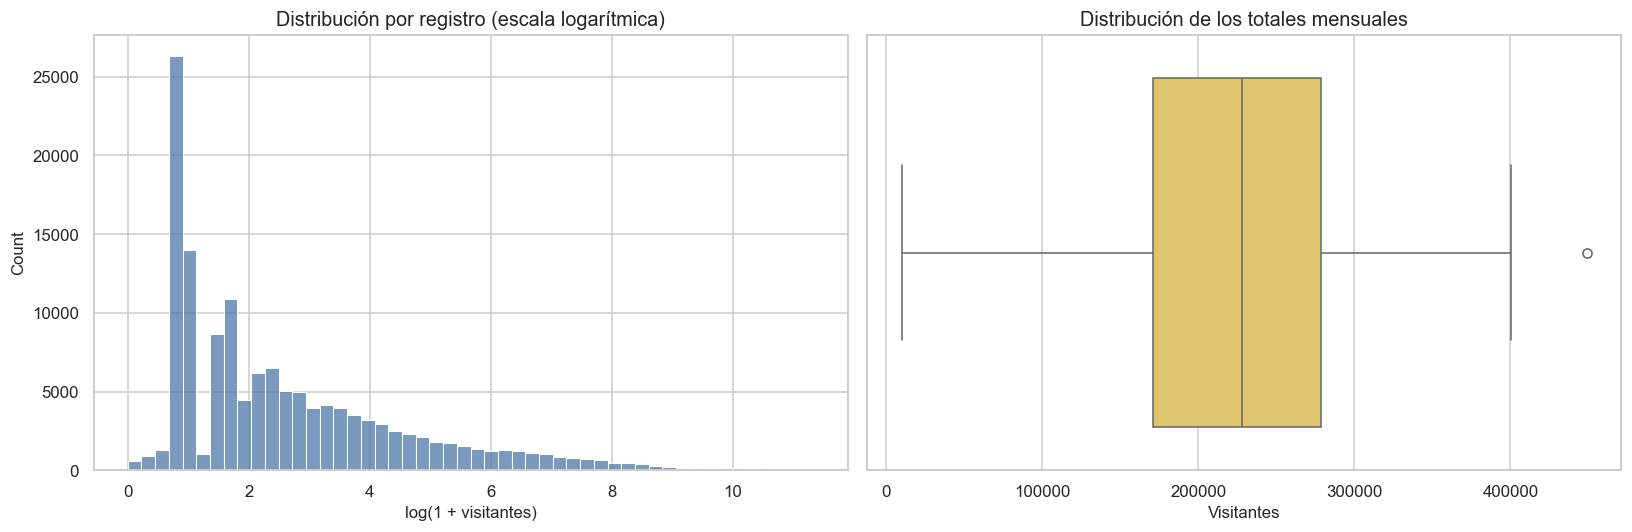

In [11]:
# Inciso: 1(e) y 1(f) — Diagnóstico y visualización de atípicos
def limites_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lim_inf_fila, lim_sup_fila = limites_iqr(visitantes["Viajero"])
lim_inf_mes, lim_sup_mes = limites_iqr(serie_mensual)

atipicos_fila = visitantes.loc[
    (visitantes["Viajero"] < lim_inf_fila)
    | (visitantes["Viajero"] > lim_sup_fila)
]
atipicos_mes = serie_mensual.loc[
    (serie_mensual < lim_inf_mes) | (serie_mensual > lim_sup_mes)
]

resumen_atipicos = pd.Series({
    "Límite superior por registro": lim_sup_fila,
    "Registros marcados por IQR": len(atipicos_fila),
    "Porcentaje de registros marcados": 100 * len(atipicos_fila) / len(visitantes),
    "Límite superior mensual": lim_sup_mes,
    "Meses marcados por IQR": len(atipicos_mes)
}, name="Valor")
display(resumen_atipicos.to_frame())
display(atipicos_mes.to_frame("Visitantes"))
display(
    atipicos_fila.nlargest(10, "Viajero")[
        ["Fecha", "Vía", "Frontera", "País", "Región dos",
         "Tipo de Viajero", "Viajero"]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(np.log1p(visitantes["Viajero"]), bins=50, ax=axes[0], color="#4C78A8")
axes[0].set(
    title="Distribución por registro (escala logarítmica)",
    xlabel="log(1 + visitantes)"
)
sns.boxplot(x=serie_mensual.values, ax=axes[1], color="#F2CF5B")
axes[1].set(
    title="Distribución de los totales mensuales",
    xlabel="Visitantes"
)
plt.tight_layout()
plt.show()

### Inciso: 1(e) — Interpretación de atípicos

La asimetría por registro es esperable: existen muchas combinaciones pequeñas y pocas combinaciones de mercados masivos. Por ello, eliminar todos los registros marcados por IQR destruiría señal real. Los meses extremos se conservan y se interpretan en su contexto temporal.

### Inciso: 2 — División entrenamiento/prueba

## 9. División cronológica de entrenamiento y prueba

La partición respeta el orden temporal para impedir que información futura entre al entrenamiento. El 70% inicial de los meses se usa para entrenar y el 30% final para prueba, todas las filas de un mismo mes permanecen en el mismo conjunto.

,Conjunto,Inicio,Fin,Meses,Porcentaje de meses,Filas
0,Entrenamiento,2009-01-01,2021-03-01,147,70.00,116966
1,Prueba,2021-04-01,2026-06-01,63,30.00,20676


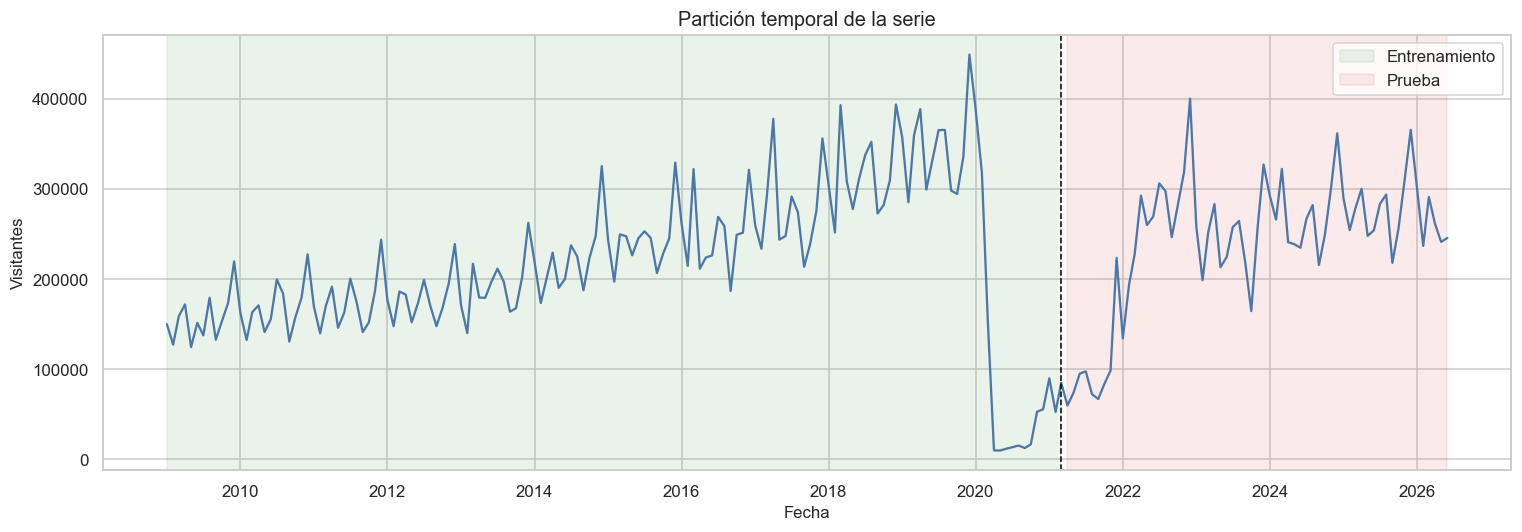

In [12]:
# Inciso: 2 — División entrenamiento/prueba
fechas = pd.DatetimeIndex(sorted(visitantes["Fecha"].unique()))
n_train = int(np.floor(0.70 * len(fechas)))
fechas_train = fechas[:n_train]
fechas_test = fechas[n_train:]
fecha_corte = fechas_train[-1]

train = visitantes.loc[visitantes["Fecha"].isin(fechas_train)].copy()
test = visitantes.loc[visitantes["Fecha"].isin(fechas_test)].copy()

particion = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Inicio": [fechas_train.min(), fechas_test.min()],
    "Fin": [fechas_train.max(), fechas_test.max()],
    "Meses": [len(fechas_train), len(fechas_test)],
    "Porcentaje de meses": [
        100 * len(fechas_train) / len(fechas),
        100 * len(fechas_test) / len(fechas)
    ],
    "Filas": [len(train), len(test)]
})
display(particion)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_mensual, color="#4C78A8", lw=1.5)
ax.axvspan(fechas_train.min(), fechas_train.max(), color="#59A14F",
           alpha=0.12, label="Entrenamiento")
ax.axvspan(fechas_test.min(), fechas_test.max(), color="#E15759",
           alpha=0.12, label="Prueba")
ax.axvline(fecha_corte, color="black", ls="--", lw=1)
ax.set(
    title="Partición temporal de la serie",
    xlabel="Fecha",
    ylabel="Visitantes"
)
ax.legend()
plt.tight_layout()
plt.show()

### Inciso: 2 — Interpretación de la partición

La prueba comienza inmediatamente después del último mes de entrenamiento. Esta partición es exigente: el entrenamiento termina cerca del período de disrupción, mientras que la prueba contiene buena parte de la recuperación y un entorno de nivel distinto. Esa dificultad representa un cambio estructural real y deberá considerarse al evaluar pronósticos.

### Inciso: 3(a) y 3(b) — Construcción de series mensuales

## 10. Construcción de las series mensuales

Se construye una serie total y dos categorías completas: las tres vías de ingreso y las tres regiones con mayor volumen acumulado. El Top 3 regional se determina con todo el período para que el ranking no dependa de un año particular, los valores mensuales usados para modelar proceden únicamente del entrenamiento.

In [13]:
# Inciso: 3(a), 3(b-ii) y 3(b-iii) — Construcción de series
indice_train = pd.date_range(fechas_train.min(), fechas_train.max(), freq="MS")

top3_regiones = (
    visitantes.groupby("Región dos")["Viajero"]
              .sum()
              .nlargest(3)
              .index
              .tolist()
)
vias_requeridas = ["Aérea", "Terrestre", "Marítima"]

serie_total_train = (
    train.groupby("Fecha")["Viajero"]
         .sum()
         .reindex(indice_train, fill_value=0)
         .rename("Total")
)

series_via_train = (
    train.pivot_table(
        index="Fecha", columns="Vía", values="Viajero",
        aggfunc="sum", fill_value=0
    )
    .reindex(index=indice_train, columns=vias_requeridas, fill_value=0)
)

series_region_train = (
    train.loc[train["Región dos"].isin(top3_regiones)]
         .pivot_table(
             index="Fecha", columns="Región dos", values="Viajero",
             aggfunc="sum", fill_value=0
         )
         .reindex(index=indice_train, columns=top3_regiones, fill_value=0)
)

series_construidas = {"Total": serie_total_train}
series_construidas.update({
    f"Vía — {col}": series_via_train[col] for col in series_via_train
})
series_construidas.update({
    f"Región — {col}": series_region_train[col] for col in series_region_train
})

metadatos_series = pd.DataFrame([
    {
        "Serie": nombre,
        "Inicio": serie.index.min(),
        "Fin": serie.index.max(),
        "Frecuencia": "Mensual (MS)",
        "Observaciones": len(serie),
        "Meses faltantes": int(serie.isna().sum())
    }
    for nombre, serie in series_construidas.items()
])

print("Top 3 de regiones:", ", ".join(top3_regiones))
display(metadatos_series)

Top 3 de regiones: América Del Centro, América Del Norte, Europa


,Serie,Inicio,Fin,Frecuencia,Observaciones,Meses faltantes
0,Total,2009-01-01,2021-03-01,Mensual (MS),147,0
1,Vía — Aérea,2009-01-01,2021-03-01,Mensual (MS),147,0
2,Vía — Terrestre,2009-01-01,2021-03-01,Mensual (MS),147,0
3,Vía — Marítima,2009-01-01,2021-03-01,Mensual (MS),147,0
4,Región — América Del Centro,2009-01-01,2021-03-01,Mensual (MS),147,0
5,Región — América Del Norte,2009-01-01,2021-03-01,Mensual (MS),147,0
6,Región — Europa,2009-01-01,2021-03-01,Mensual (MS),147,0


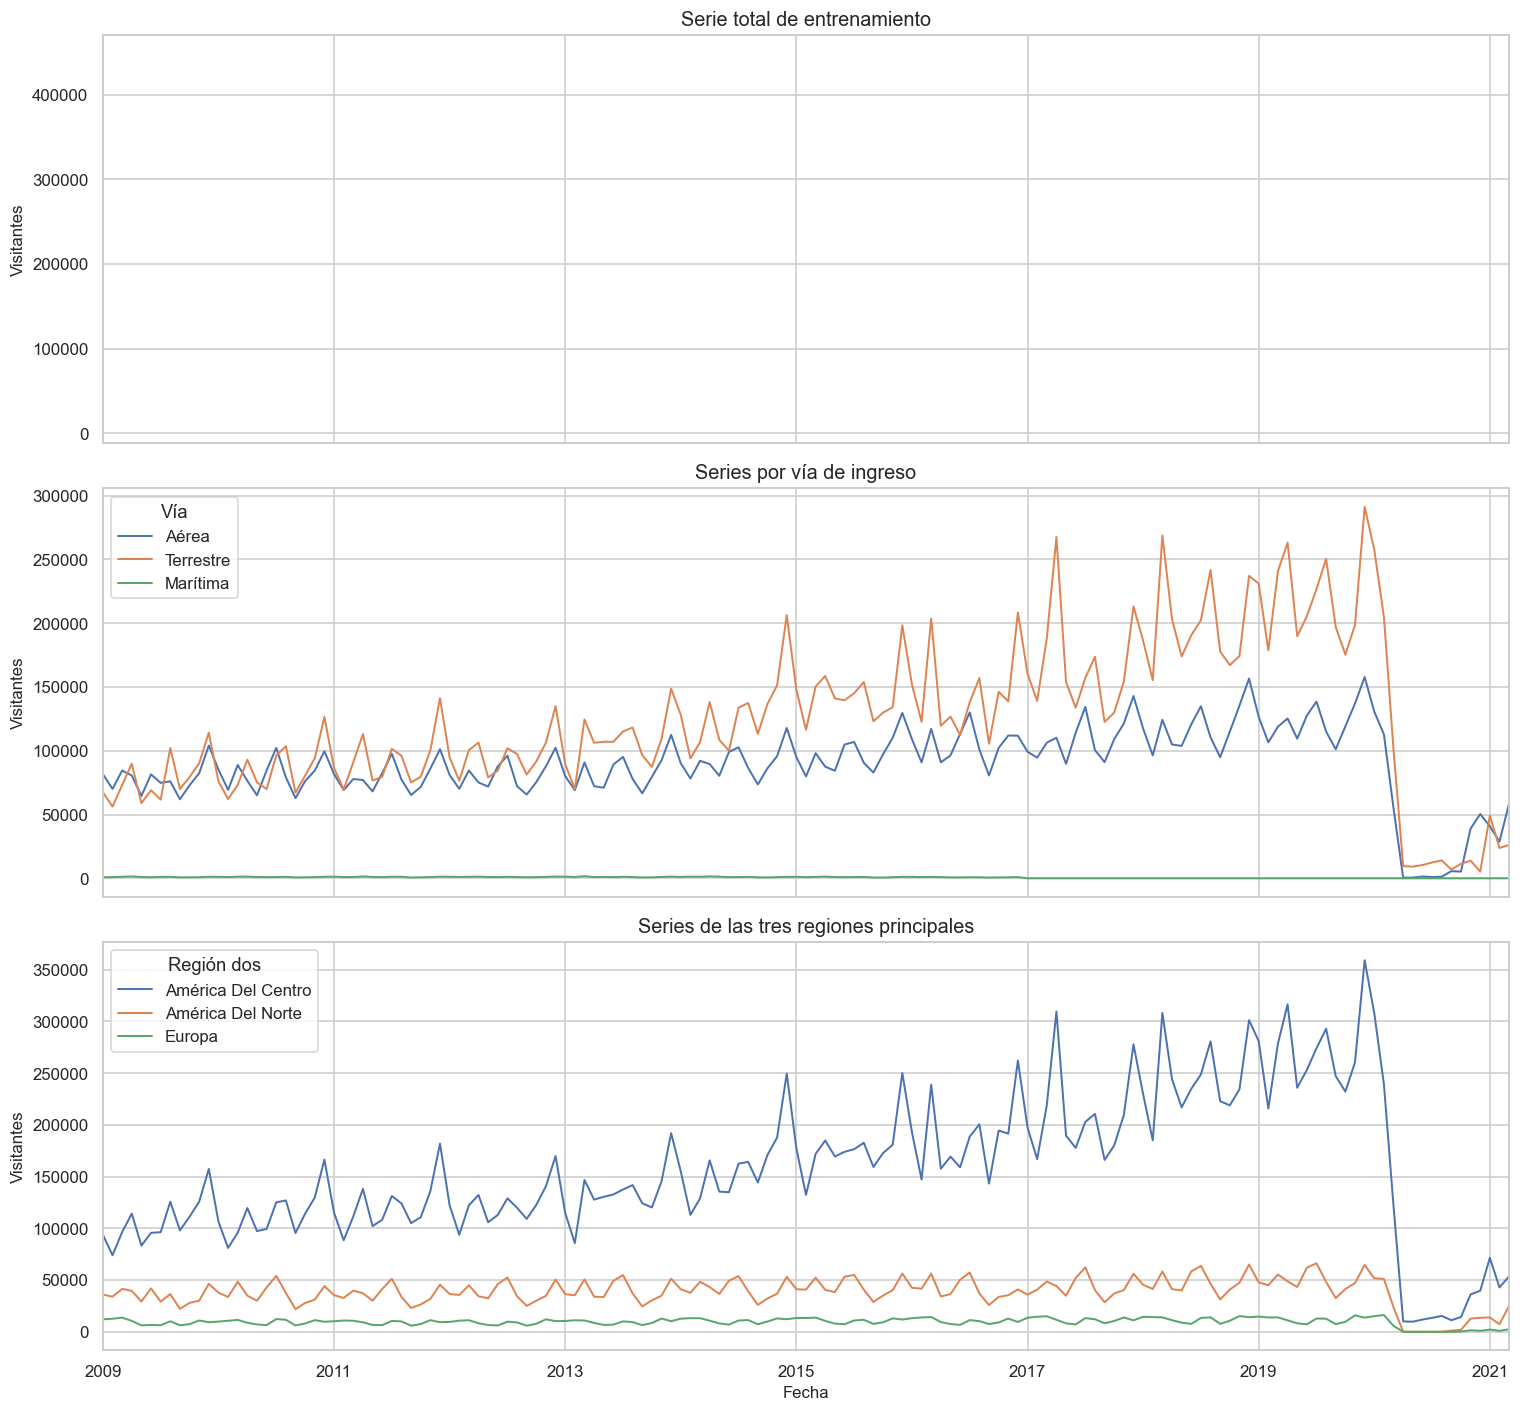

In [14]:
# Inciso: 3(a), 3(b-ii) y 3(b-iii) — Visualización de series
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

axes[0].plot(serie_total_train, color="#222222", lw=1.5)
axes[0].set_title("Serie total de entrenamiento")
axes[0].set_ylabel("Visitantes")

series_via_train.plot(ax=axes[1], lw=1.3)
axes[1].set_title("Series por vía de ingreso")
axes[1].set_ylabel("Visitantes")

series_region_train.plot(ax=axes[2], lw=1.3)
axes[2].set_title("Series de las tres regiones principales")
axes[2].set_ylabel("Visitantes")
axes[2].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

### Inciso: 3 — Validación de las series construidas

Las series no presentan huecos y comparten inicio, fin y frecuencia, lo que permite compararlas directamente. La suma por vía coincide con el total mensual, las tres regiones principales son subconjuntos y no necesariamente cubren el cien por ciento.

### Inciso: 4(a)–4(k) — Análisis completo de regiones

## 11. Análisis completo de las series regionales

El análisis se concentra en las tres regiones con mayor volumen acumulado: `América Del Centro`, `América Del Norte` y `Europa`. Todos los modelos aprenden exclusivamente del período de entrenamiento, el período de prueba se reserva para medir capacidad predictiva fuera de muestra.

In [15]:
# Inciso: 4(a) — Inicio, fin y frecuencia
import logging
from IPython.display import Markdown
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet


def fuerza_componentes(descomp):
    residuo = descomp.resid.dropna()
    tendencia = descomp.trend.reindex(residuo.index)
    estacional = descomp.seasonal.reindex(residuo.index)
    fuerza_tendencia = max(
        0, 1 - np.var(residuo) / np.var(tendencia + residuo)
    )
    fuerza_estacional = max(
        0, 1 - np.var(residuo) / np.var(estacional + residuo)
    )
    return fuerza_tendencia, fuerza_estacional


def resultado_adf(serie, etiqueta):
    limpia = pd.Series(serie).dropna()
    estadistico, pvalor, rezagos, nobs, *_ = adfuller(
        limpia, autolag="AIC"
    )
    return {
        "Transformación": etiqueta,
        "Estadístico ADF": estadistico,
        "p-valor": pvalor,
        "Rezagos": rezagos,
        "Observaciones": nobs,
        "Estacionaria al 5%": pvalor < 0.05
    }


logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").disabled = True

indice_test = pd.date_range(fechas_test.min(), fechas_test.max(), freq="MS")
indice_completo = pd.date_range(fechas.min(), fechas.max(), freq="MS")

series_region_test = (
    test.loc[test["Región dos"].isin(top3_regiones)]
        .pivot_table(
            index="Fecha", columns="Región dos", values="Viajero",
            aggfunc="sum", fill_value=0
        )
        .reindex(index=indice_test, columns=top3_regiones, fill_value=0)
        .astype(float)
)

series_region_full = (
    visitantes.loc[visitantes["Región dos"].isin(top3_regiones)]
        .pivot_table(
            index="Fecha", columns="Región dos", values="Viajero",
            aggfunc="sum", fill_value=0
        )
        .reindex(index=indice_completo, columns=top3_regiones, fill_value=0)
        .astype(float)
)

series_region_train = series_region_train.astype(float)

metadatos_regionales = pd.DataFrame([
    {
        "Región": region,
        "Inicio entrenamiento": series_region_train.index.min(),
        "Fin entrenamiento": series_region_train.index.max(),
        "Inicio prueba": series_region_test.index.min(),
        "Fin prueba": series_region_test.index.max(),
        "Frecuencia": "Mensual",
        "Meses entrenamiento": len(series_region_train),
        "Meses prueba": len(series_region_test),
        "Faltantes": (
            series_region_train[region].isna().sum()
            + series_region_test[region].isna().sum()
        )
    }
    for region in top3_regiones
])
display(metadatos_regionales)


,Región,Inicio entrenamiento,Fin entrenamiento,Inicio prueba,Fin prueba,Frecuencia,Meses entrenamiento,Meses prueba,Faltantes
0,América Del Centro,2009-01-01,2021-03-01,2021-04-01,2026-06-01,Mensual,147,63,0
1,América Del Norte,2009-01-01,2021-03-01,2021-04-01,2026-06-01,Mensual,147,63,0
2,Europa,2009-01-01,2021-03-01,2021-04-01,2026-06-01,Mensual,147,63,0


### Inciso: 4(b) — Gráfico y lectura inicial

### Cobertura y lectura inicial

Cada serie comienza en enero de 2009, tiene frecuencia mensual y conserva una observación por mes. La línea vertical separa entrenamiento y prueba, la franja gris identifica el choque sanitario.

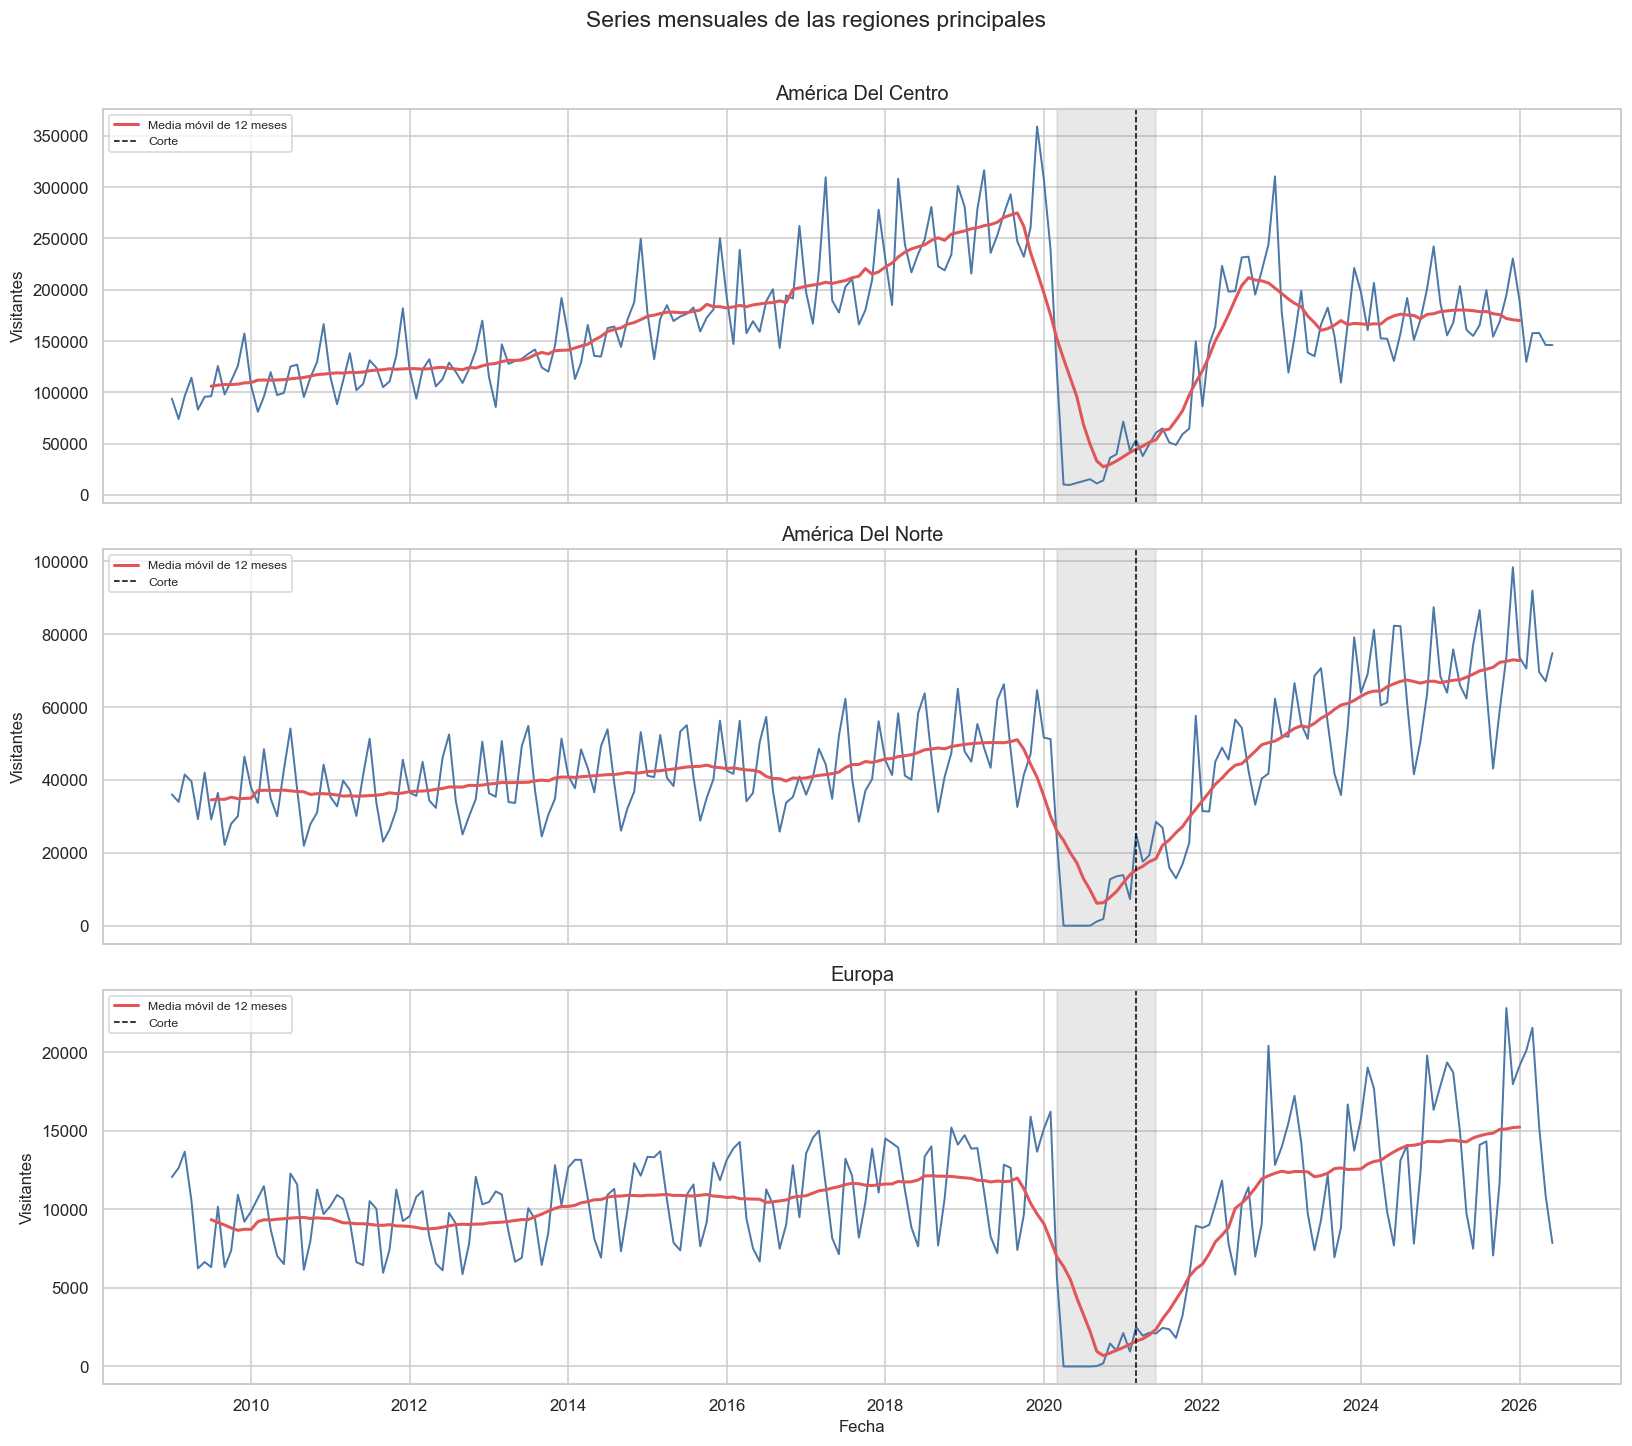

In [16]:
# Inciso: 4(b) — Gráfico de las series regionales
fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)

for ax, region in zip(axes, top3_regiones):
    serie = series_region_full[region]
    ax.plot(serie, color="#4C78A8", lw=1.3)
    ax.plot(
        serie.rolling(12, center=True).mean(),
        color="#E15759", lw=2, label="Media móvil de 12 meses"
    )
    ax.axvspan(
        pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
        color="gray", alpha=0.18
    )
    ax.axvline(fecha_corte, color="black", ls="--", lw=1, label="Corte")
    ax.set_title(region)
    ax.set_ylabel("Visitantes")
    ax.legend(loc="upper left", fontsize=8)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Series mensuales de las regiones principales", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

### Inciso: 4(b) — Interpretación inicial

Las tres regiones exhiben crecimiento antes de 2020, ciclos anuales y una caída abrupta que no corresponde a estacionalidad. América Del Centro posee la mayor escala y una fuerte dependencia del flujo terrestre, América Del Norte y Europa tienen menor volumen y una participación aérea más alta. La recuperación ocurre dentro del conjunto de prueba, por lo que constituye un desafío de cambio estructural para todos los modelos.

### Inciso: 4(c) — Descomposición y componentes

### Componentes, tendencia y estacionalidad

La descomposición aditiva usa un período de 12 meses. La fuerza de tendencia y la fuerza estacional toman valores entre 0 y 1: valores altos indican que el componente explica una proporción importante de la variación frente al residuo.

,Fuerza de tendencia,Fuerza de estacionalidad,Mes estacional máximo,Mes estacional mínimo
Región,,,,
América Del Centro,0.77,0.36,12,9
América Del Norte,0.64,0.57,12,9
Europa,0.81,0.76,2,6


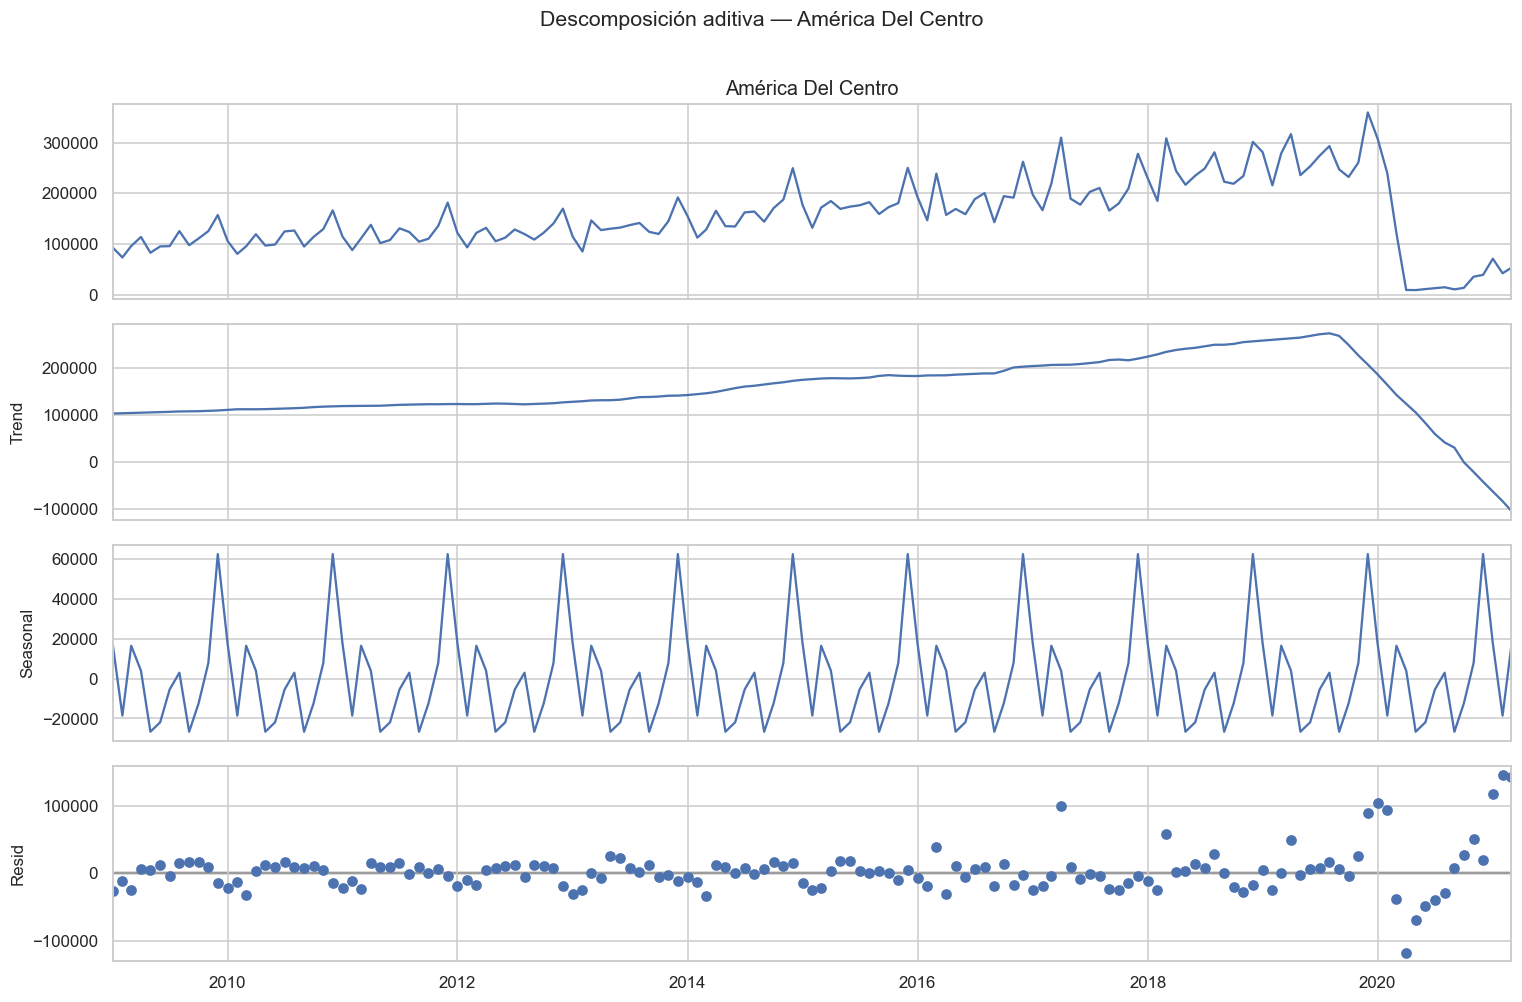

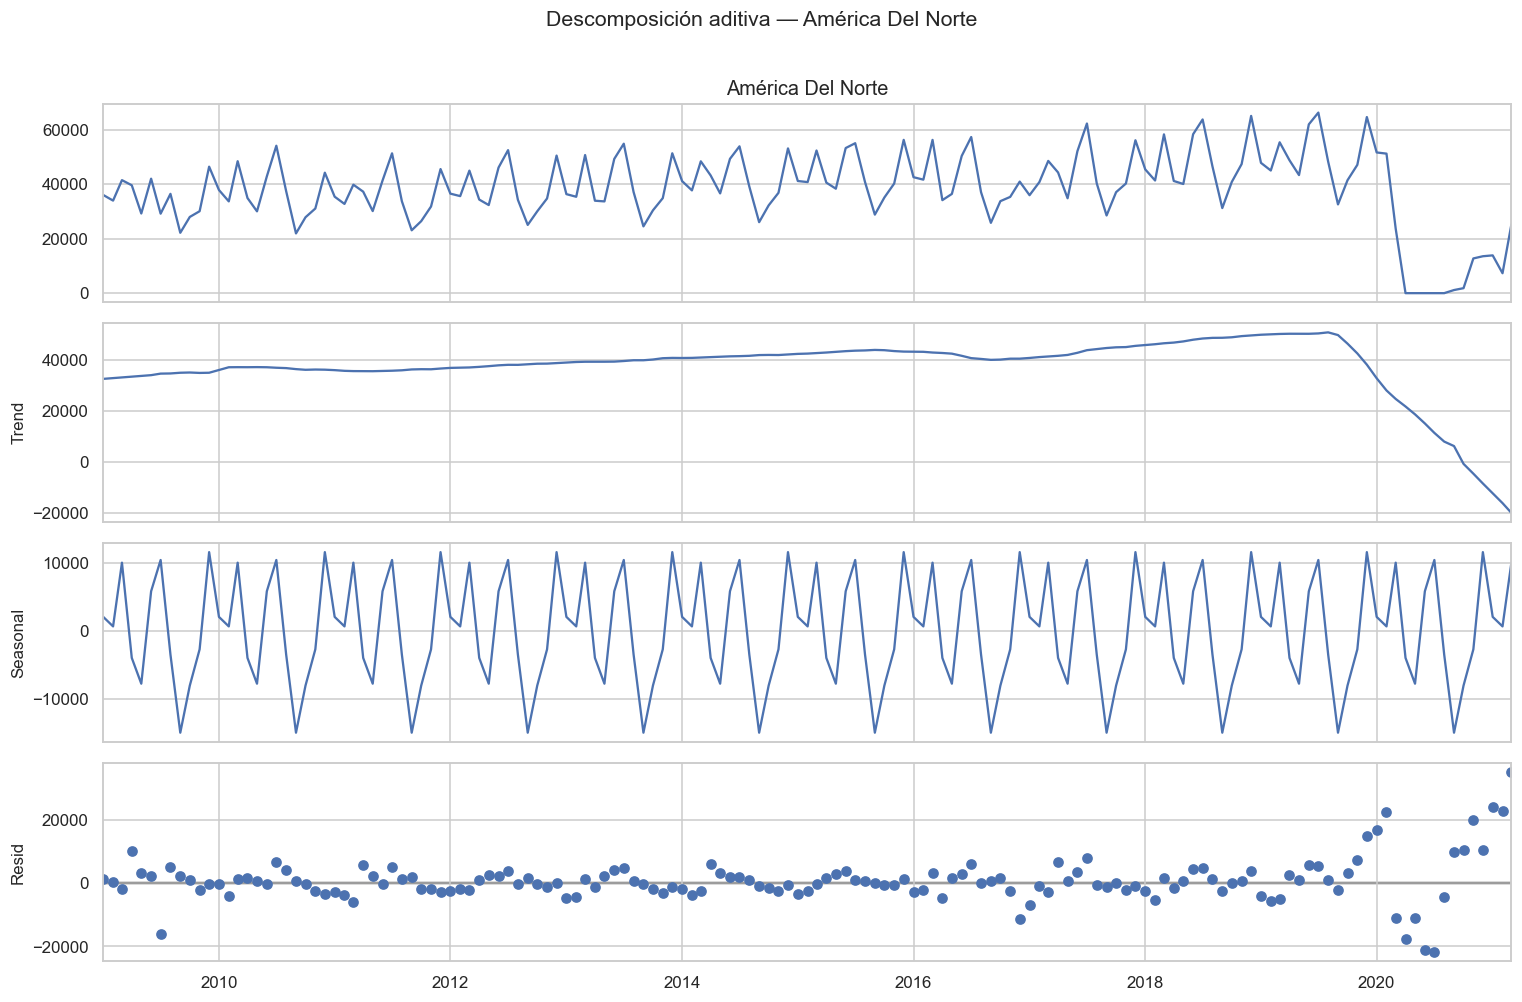

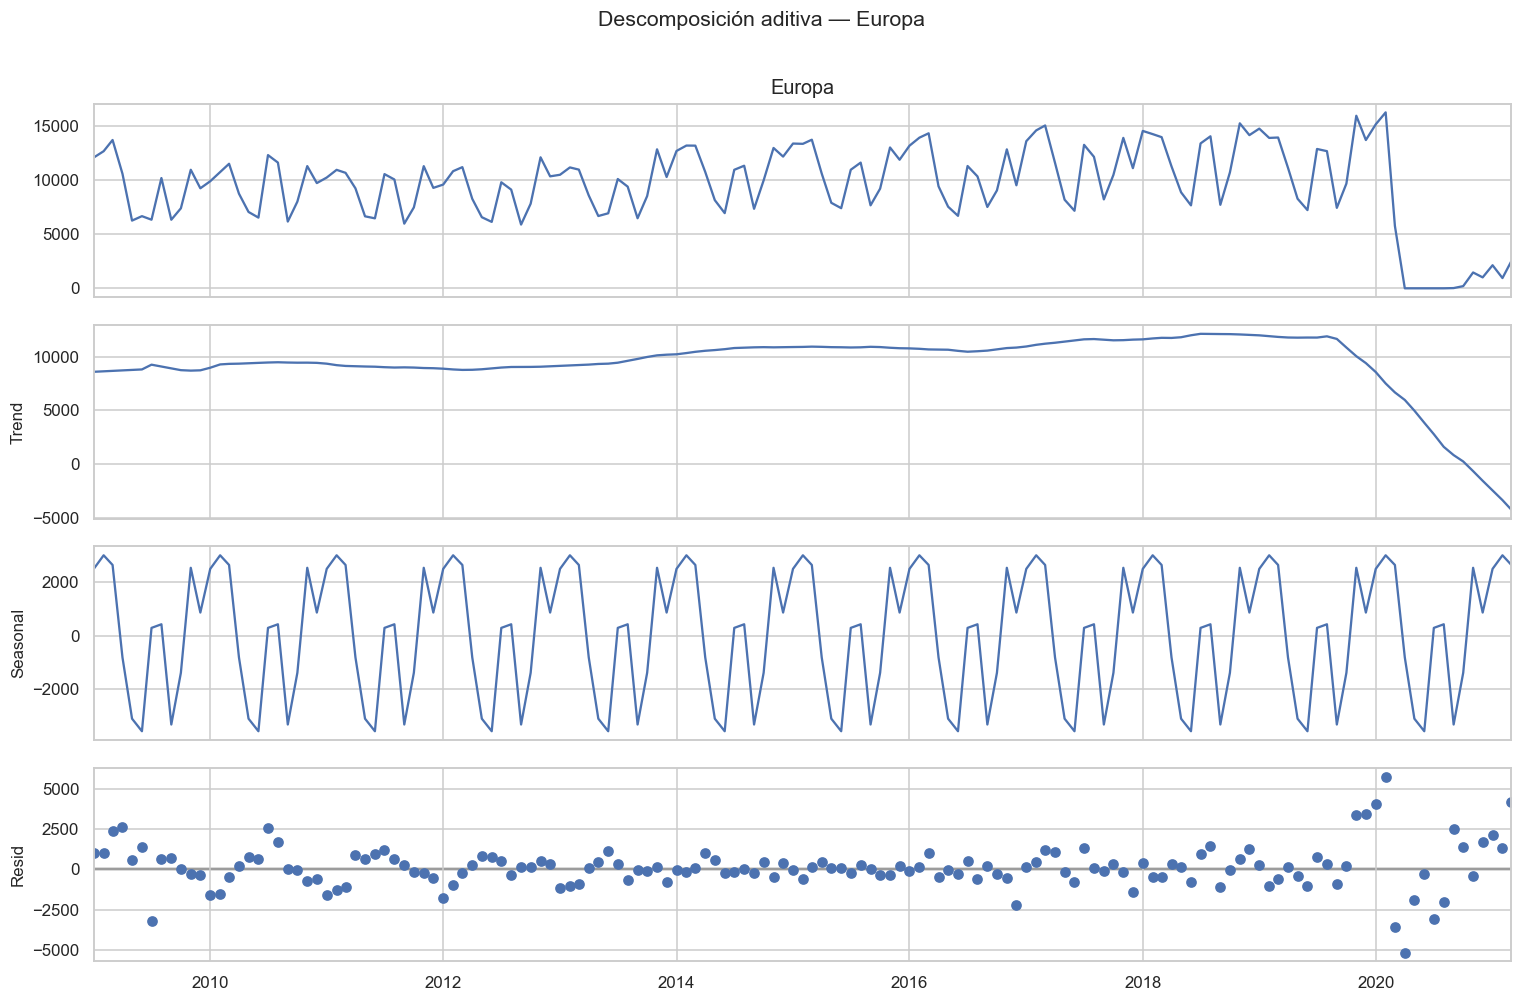

In [17]:
# Inciso: 4(c) — Descomposición regional
descomposicion_regional = {}
resumen_componentes = []

for region in top3_regiones:
    serie = series_region_train[region]
    descomp = seasonal_decompose(
        serie, model="additive", period=12, extrapolate_trend="freq"
    )
    descomposicion_regional[region] = descomp
    fuerza_tendencia, fuerza_estacional = fuerza_componentes(descomp)
    resumen_componentes.append({
        "Región": region,
        "Fuerza de tendencia": fuerza_tendencia,
        "Fuerza de estacionalidad": fuerza_estacional,
        "Mes estacional máximo": descomp.seasonal.groupby(
            descomp.seasonal.index.month
        ).mean().idxmax(),
        "Mes estacional mínimo": descomp.seasonal.groupby(
            descomp.seasonal.index.month
        ).mean().idxmin()
    })

resumen_componentes = pd.DataFrame(resumen_componentes).set_index("Región")
display(resumen_componentes)

for region, descomp in descomposicion_regional.items():
    fig = descomp.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle(f"Descomposición aditiva — {region}", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

In [18]:
# Inciso: 4(c) — Interpretación de tendencia y estacionalidad
region_mas_estacional = resumen_componentes[
    "Fuerza de estacionalidad"
].idxmax()
region_mas_tendencia = resumen_componentes[
    "Fuerza de tendencia"
].idxmax()

display(Markdown(
    f"**Interpretación.** Las tres series contienen tendencia y estacionalidad "
    f"anual. La mayor fuerza estacional dentro del entrenamiento corresponde a "
    f"**{region_mas_estacional}** "
    f"({resumen_componentes.loc[region_mas_estacional, 'Fuerza de estacionalidad']:.3f}). "
    f"La tendencia más fuerte corresponde a **{region_mas_tendencia}** "
    f"({resumen_componentes.loc[region_mas_tendencia, 'Fuerza de tendencia']:.3f}). "
    f"El choque de 2020 queda principalmente en tendencia y residuo porque no es "
    f"un ciclo que se repita cada doce meses."
))

**Interpretación.** Las tres series contienen tendencia y estacionalidad anual. La mayor fuerza estacional dentro del entrenamiento corresponde a **Europa** (0.757). La tendencia más fuerte corresponde a **Europa** (0.814). El choque de 2020 queda principalmente en tendencia y residuo porque no es un ciclo que se repita cada doce meses.

### Inciso: 4(c) y 4(d) — Varianza y transformación

### Estacionariedad en varianza y transformación

Se examina si la dispersión aumenta junto con el nivel mediante la correlación entre media y desviación móvil de 12 meses. También se estima el parámetro de Box-Cox, valores cercanos a cero respaldan una transformación logarítmica. Para conservar meses con valor cero, se usa `log(1+x)`.

,Correlación media-desv. móvil,Lambda Box-Cox,CV primera mitad,CV segunda mitad,Transformación aplicada
Región,,,,,
América Del Centro,0.15,0.88,0.24,0.46,log(1+x)
América Del Norte,-0.34,1.53,0.22,0.45,log(1+x)
Europa,-0.23,1.68,0.23,0.49,log(1+x)


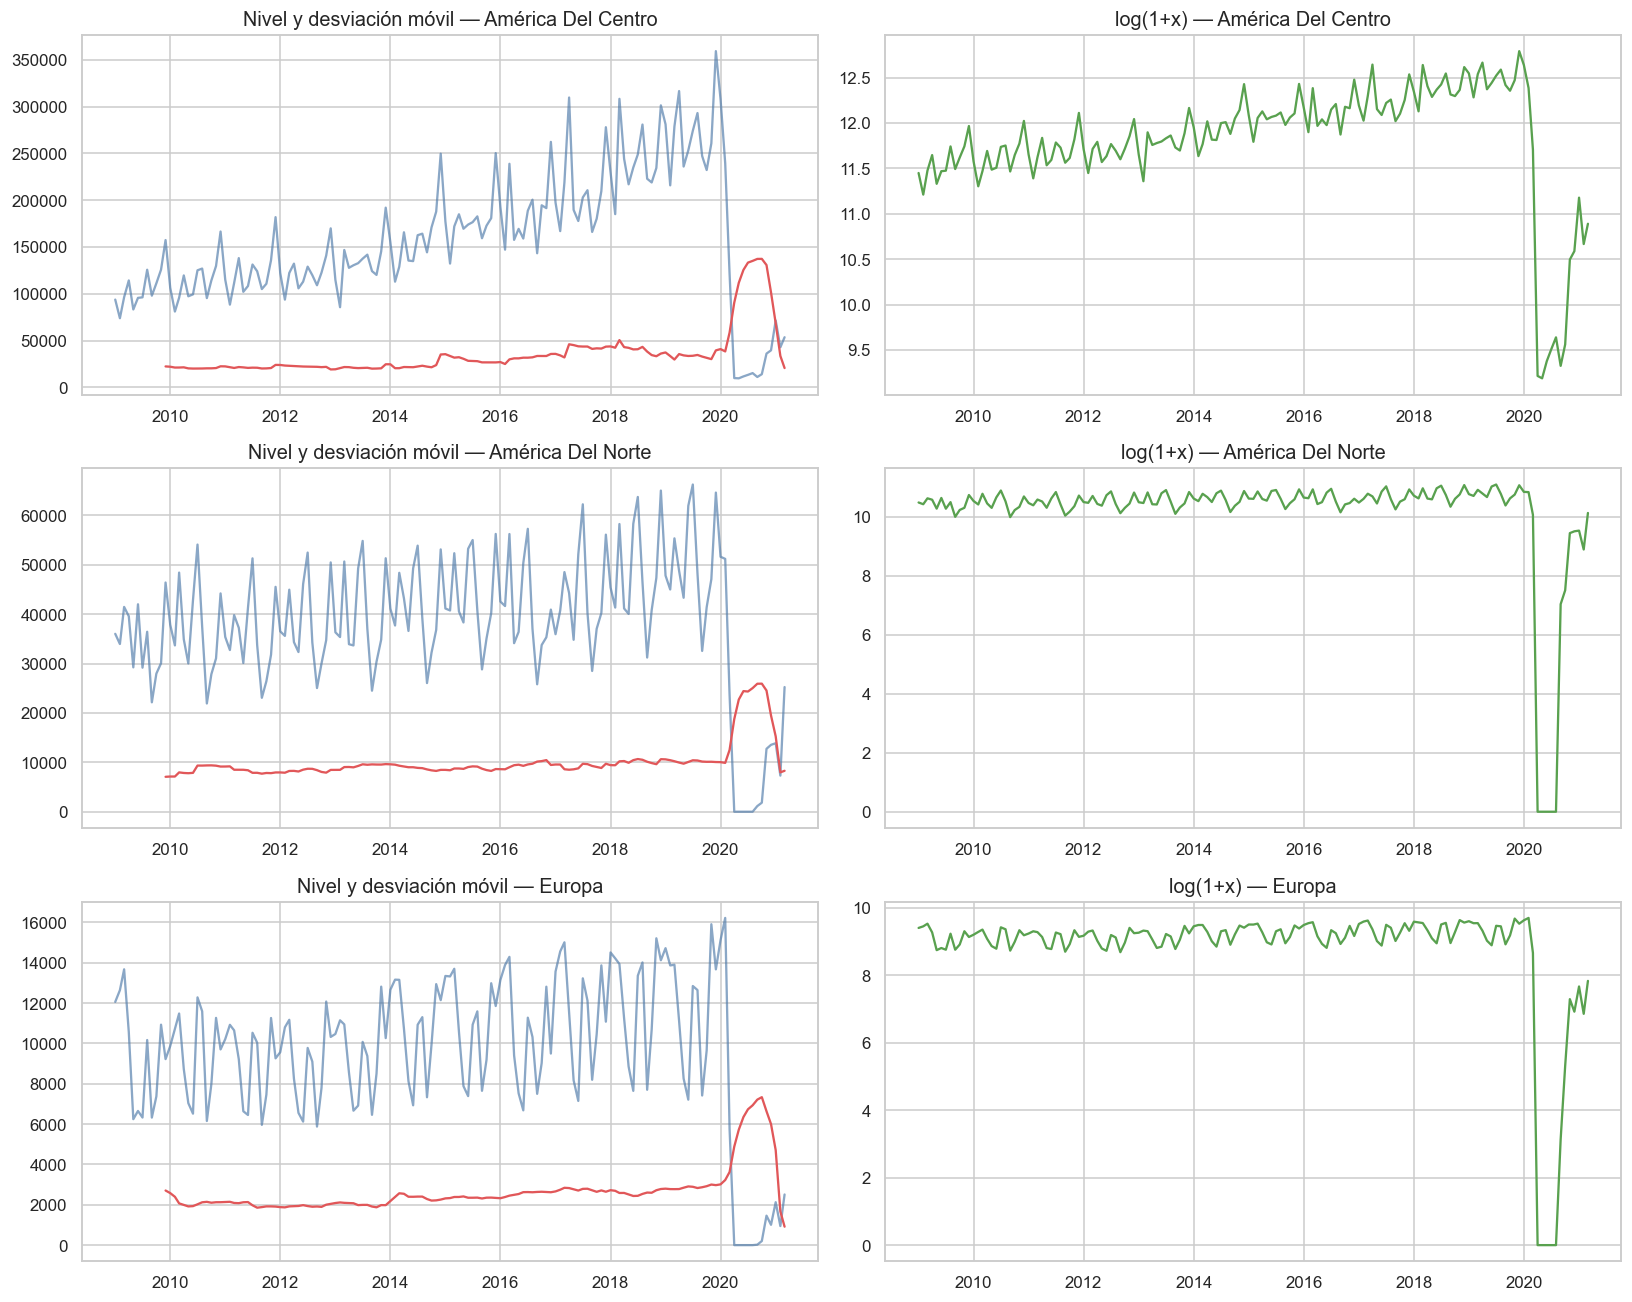

In [19]:
# Inciso: 4(c) y 4(d) — Diagnóstico de varianza
diagnostico_varianza = []

for region in top3_regiones:
    serie = series_region_train[region].astype(float)
    media_rodante = serie.rolling(12).mean()
    std_rodante = serie.rolling(12).std()
    lambda_boxcox = stats.boxcox_normmax(serie.clip(lower=0) + 1)
    mitad = len(serie) // 2

    diagnostico_varianza.append({
        "Región": region,
        "Correlación media-desv. móvil": media_rodante.corr(std_rodante),
        "Lambda Box-Cox": lambda_boxcox,
        "CV primera mitad": serie.iloc[:mitad].std() / serie.iloc[:mitad].mean(),
        "CV segunda mitad": serie.iloc[mitad:].std() / serie.iloc[mitad:].mean(),
        "Transformación aplicada": "log(1+x)"
    })

diagnostico_varianza = pd.DataFrame(diagnostico_varianza).set_index("Región")
display(diagnostico_varianza)

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for fila, region in enumerate(top3_regiones):
    original = series_region_train[region]
    transformada = np.log1p(original)

    axes[fila, 0].plot(original, color="#4C78A8", alpha=0.65)
    axes[fila, 0].plot(original.rolling(12).std(), color="#E15759")
    axes[fila, 0].set_title(f"Nivel y desviación móvil — {region}")

    axes[fila, 1].plot(transformada, color="#59A14F")
    axes[fila, 1].set_title(f"log(1+x) — {region}")

plt.tight_layout()
plt.show()

### Inciso: 4(d) — Decisión de transformación

Los valores de Box-Cox no se aproximan a cero y la relación entre media y desviación móvil es débil, por ello, la evidencia no indica que una transformación logarítmica sea estrictamente necesaria para estabilizar la varianza de ninguna región. Aun así, se usa `log(1+x)` como decisión conservadora de modelado: reduce la influencia del choque extremo de 2020, representa cambios relativos y permite regresar a una escala no negativa. Esta elección se distingue de afirmar que la varianza obliga a transformar.

### Inciso: 4(e) — Estacionariedad en media

### Estacionariedad en media

La prueba ADF contrasta la presencia de raíz unitaria. Se evalúan el nivel, el logaritmo, la primera diferencia logarítmica, la diferencia estacional de 12 meses y la combinación de ambas. Un valor p menor que 0.05 rechaza la hipótesis de raíz unitaria.

In [20]:
# Inciso: 4(e-ii) — Prueba ADF y diferenciación
filas_adf_regiones = []
orden_d = {}

for region in top3_regiones:
    nivel = series_region_train[region]
    log_nivel = np.log1p(nivel)
    transformaciones = {
        "Nivel": nivel,
        "log(1+x)": log_nivel,
        "Δ log(1+x)": log_nivel.diff(),
        "Δ12 log(1+x)": log_nivel.diff(12),
        "Δ Δ12 log(1+x)": log_nivel.diff(12).diff()
    }

    pvalores = {}
    for nombre, serie in transformaciones.items():
        resultado = resultado_adf(serie, nombre)
        pvalores[nombre] = resultado["p-valor"]
        filas_adf_regiones.append({"Región": region, **resultado})

    if pvalores["Δ12 log(1+x)"] < 0.05:
        orden_d[region] = 0
    elif pvalores["Δ Δ12 log(1+x)"] < 0.05:
        orden_d[region] = 1
    else:
        orden_d[region] = 2

tabla_adf_regiones = pd.DataFrame(filas_adf_regiones)
display(
    tabla_adf_regiones.set_index(["Región", "Transformación"])[
        ["Estadístico ADF", "p-valor", "Rezagos", "Estacionaria al 5%"]
    ]
)
display(pd.Series(orden_d, name="d sugerido").to_frame())

Estadístico ADF  p-valor  Rezagos  \
Región             Transformación                                      
América Del Centro Nivel                     -2.18     0.21       13   
                   log(1+x)                  -2.22     0.20       12   
                   Δ log(1+x)                -2.99     0.04       11   
                   Δ12 log(1+x)               0.19     0.97       12   
                   Δ Δ12 log(1+x)            -6.27     0.00       11   
América Del Norte  Nivel                     -3.42     0.01       13   
                   log(1+x)                  -2.35     0.16       12   
                   Δ log(1+x)                -2.87     0.05       11   
                   Δ12 log(1+x)              -0.20     0.94       12   
                   Δ Δ12 log(1+x)            -4.98     0.00       11   
Europa             Nivel                     -2.47     0.12       14   
                   log(1+x)                  -2.00     0.28       12   
                   Δ log(1+x)                -2.51     0.11       11   
                   Δ12 log(1+x)              -3.88     0.00       10   
                   Δ Δ12 log(1+x)            -4.98     0.00       10   

                                   Estacionaria al 5%  
Región             Transformación                      
América Del Centro Nivel                        False  
                   log(1+x)                     False  
                   Δ log(1+x)                    True  
                   Δ12 log(1+x)                 False  
                   Δ Δ12 log(1+x)                True  
América Del Norte  Nivel                         True  
                   log(1+x)                     False  
                   Δ log(1+x)                    True  
                   Δ12 log(1+x)                 False  
                   Δ Δ12 log(1+x)                True  
Europa             Nivel                        False  
                   log(1+x)                     False  
                   Δ log(1+x)                   False  
                   Δ12 log(1+x)                  True  
                   Δ Δ12 log(1+x)                True

,d sugerido
América Del Centro,1
América Del Norte,1
Europa,0


### Inciso: 4(e-ii) — Interpretación de diferenciación

La diferenciación ordinaria elimina cambios persistentes de nivel y la diferencia de orden 12 elimina el patrón anual repetitivo. Los valores de `d` y `D` se determinan únicamente con el conjunto de entrenamiento. América Del Centro y América Del Norte requieren `d=1` y `D=1`. Europa se vuelve estacionaria con la diferencia estacional, por lo que requiere `d=0` y `D=1`.


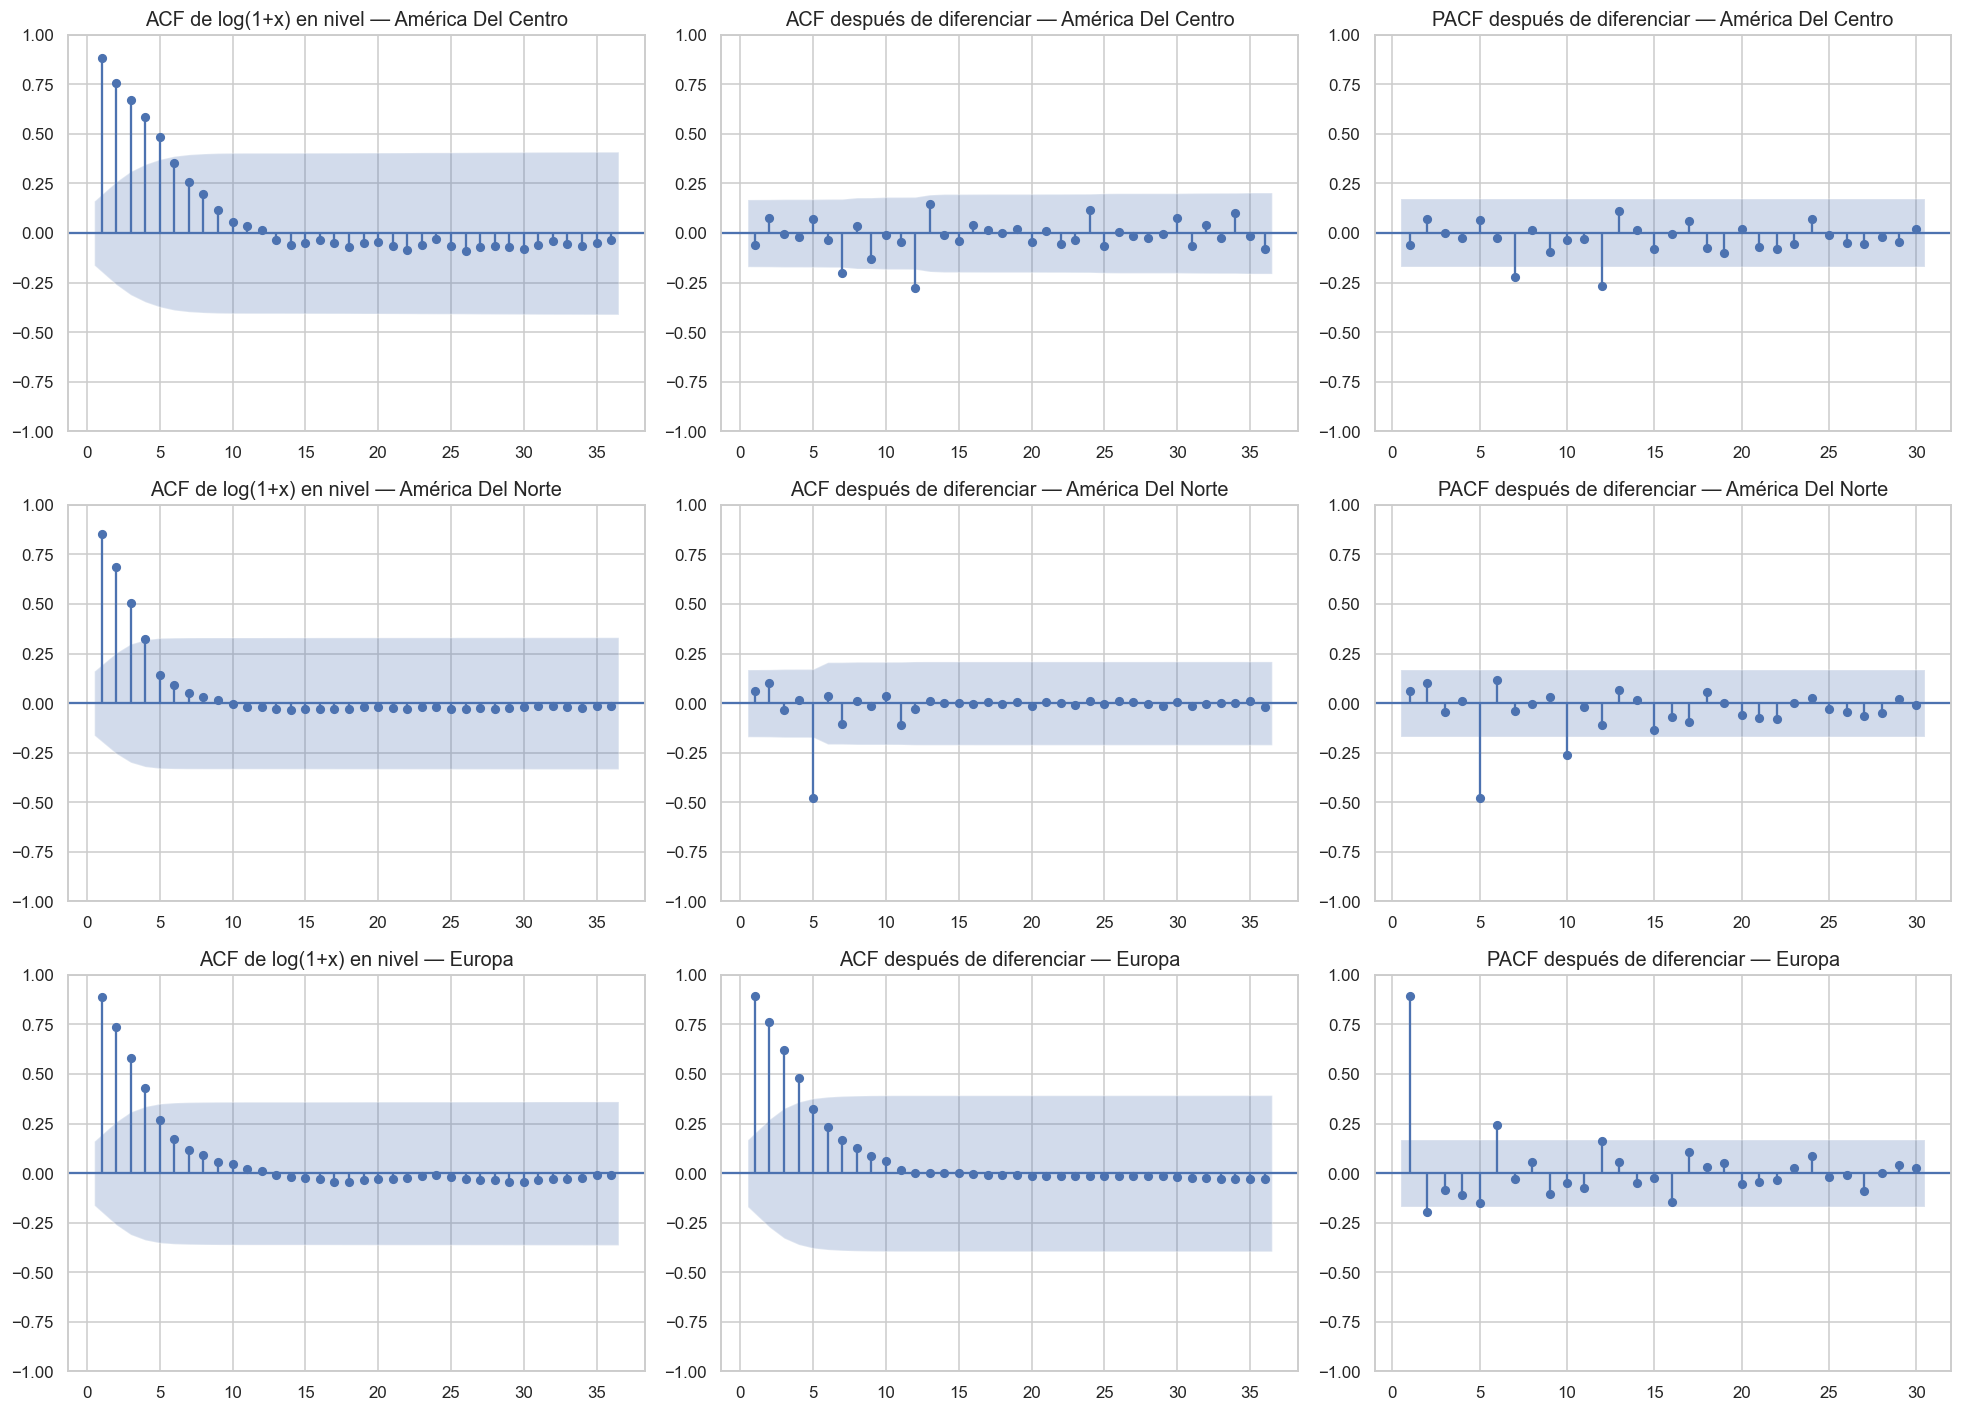

,ACF rezago 1,ACF rezago 3,ACF rezago 6,ADF p en log-nivel,Diferencia ordinaria d,Diferencia estacional D,ADF p después de diferenciar
Región,,,,,,,
América Del Centro,0.88,0.67,0.35,0.20,1,1,0.00
América Del Norte,0.85,0.51,0.09,0.16,1,1,0.00
Europa,0.89,0.58,0.17,0.28,0,1,0.00


In [21]:
# Inciso: 4(e-i) y 4(f) — ACF y PACF
from statsmodels.tsa.stattools import acf as calcular_acf

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
diagnostico_acf = []

for fila, region in enumerate(top3_regiones):
    log_nivel = np.log1p(series_region_train[region])
    valores_acf = calcular_acf(log_nivel, nlags=24, fft=True)

    estacionaria = log_nivel.diff(12)
    for _ in range(orden_d[region]):
        estacionaria = estacionaria.diff()
    estacionaria = estacionaria.dropna()

    plot_acf(log_nivel, lags=36, zero=False, ax=axes[fila, 0])
    axes[fila, 0].set_title(f"ACF de log(1+x) en nivel — {region}")

    plot_acf(estacionaria, lags=36, zero=False, ax=axes[fila, 1])
    axes[fila, 1].set_title(f"ACF después de diferenciar — {region}")

    plot_pacf(
        estacionaria, lags=min(30, len(estacionaria) // 2 - 1),
        method="ywm", zero=False, ax=axes[fila, 2]
    )
    axes[fila, 2].set_title(f"PACF después de diferenciar — {region}")

    p_log = tabla_adf_regiones.loc[
        (tabla_adf_regiones["Región"] == region)
        & (tabla_adf_regiones["Transformación"] == "log(1+x)"),
        "p-valor"
    ].iloc[0]
    transformacion_final = (
        "Δ12 log(1+x)"
        if orden_d[region] == 0
        else "Δ Δ12 log(1+x)"
    )
    p_final = tabla_adf_regiones.loc[
        (tabla_adf_regiones["Región"] == region)
        & (tabla_adf_regiones["Transformación"] == transformacion_final),
        "p-valor"
    ].iloc[0]

    diagnostico_acf.append({
        "Región": region,
        "ACF rezago 1": valores_acf[1],
        "ACF rezago 3": valores_acf[3],
        "ACF rezago 6": valores_acf[6],
        "ADF p en log-nivel": p_log,
        "Diferencia ordinaria d": orden_d[region],
        "Diferencia estacional D": 1,
        "ADF p después de diferenciar": p_final
    })

plt.tight_layout()
plt.show()

diagnostico_acf = pd.DataFrame(diagnostico_acf).set_index("Región")
display(diagnostico_acf)


### Inciso: 4(e-i) y 4(f) — Selección preliminar de órdenes

### Respuesta sobre la no estacionariedad y su corrección

Las decisiones siguientes corresponden a `log(1+x)`, que es la escala utilizada para modelar.

- **América Del Centro.** La ACF inicia en 0.883 en el rezago 1 y desciende gradualmente hasta 0.354 en el rezago 6. Esta persistencia, en lugar de un corte rápido, indica que los meses cercanos conservan fuertemente el nivel anterior y que la media no es constante. La prueba ADF del log-nivel produce un valor p aproximado de 0.20, por lo que no se rechaza la raíz unitaria. Una primera diferencia ordinaria produce un valor p aproximado de 0.04 y es suficiente para estacionariedad en media. Para retirar además el patrón anual se utiliza una diferencia estacional de 12 meses, por lo que el modelo evalúa `d=1` y `D=1`.

- **América Del Norte.** La ACF comienza en 0.853 y disminuye durante varios rezagos, lo cual muestra persistencia temporal y ausencia de un nivel estable en la escala logarítmica. El ADF del log-nivel produce un valor p aproximado de 0.16. La primera diferencia se encuentra alrededor del umbral de 0.05 y la combinación con una diferencia estacional rechaza claramente la raíz unitaria. Por ello se utilizan `d=1` y `D=1`.

- **Europa.** La ACF comienza en 0.886 y también presenta una disminución gradual, evidencia de dependencia persistente y media cambiante. El ADF del log-nivel produce un valor p aproximado de 0.28 y la primera diferencia ordinaria todavía produce un valor p aproximado de 0.11, por lo que esa diferencia no basta. La diferencia estacional de 12 meses sí rechaza la raíz unitaria con un valor p menor que 0.01. Europa necesita `D=1`, pero no una diferencia ordinaria adicional, por lo que se usa `d=0`.

Después de estas transformaciones, la ACF pierde la persistencia prolongada y la prueba ADF rechaza la raíz unitaria. Esto indica que las series transformadas son adecuadas para estimar modelos ARIMA o SARIMA. Los primeros rezagos de la ACF y PACF transformadas sirven después para explorar valores pequeños de `p` y `q`.


### Inciso: 4(f) y 4(g) — Modelos ARIMA/SARIMA

### Modelos ARIMA y SARIMA

Todos los candidatos se ajustan a `log(1+x)` con el valor de `d` obtenido mediante ADF. AIC y BIC solo se comparan entre estos modelos porque comparten datos y transformación. BIC penaliza con mayor fuerza la complejidad. La prueba de Ljung-Box evalúa autocorrelación residual, un valor p superior a 0.05 es compatible con residuos sin dependencia serial significativa.

In [22]:
# Inciso: 4(f) y 4(g) — Ajuste y comparación de ARIMA/SARIMA
def especificaciones_arima(d):
    return [
        ((0, d, 1), (0, 0, 0, 0)),
        ((1, d, 0), (0, 0, 0, 0)),
        ((1, d, 1), (0, 0, 0, 0)),
        ((2, d, 1), (0, 0, 0, 0)),
        ((0, d, 1), (0, 1, 1, 12)),
        ((1, d, 1), (0, 1, 1, 12)),
        ((1, d, 1), (1, 1, 0, 12)),
        ((2, d, 1), (0, 1, 1, 12)),
        ((1, d, 2), (0, 1, 1, 12))
    ]


def nombre_arima(order, seasonal_order):
    if seasonal_order[-1] == 0:
        return f"ARIMA{order}"
    return f"SARIMA{order}x{seasonal_order}"


ajustes_arima = {}
comparacion_arima = []

for region in top3_regiones:
    y_log = np.log1p(series_region_train[region])
    ajustes_arima[region] = {}

    for order, seasonal_order in especificaciones_arima(orden_d[region]):
        nombre = nombre_arima(order, seasonal_order)
        try:
            ajuste = SARIMAX(
                y_log,
                order=order,
                seasonal_order=seasonal_order,
                trend="c" if order[1] == 0 and seasonal_order[1] == 0 else None,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False, maxiter=300)

            residuo = ajuste.resid.dropna()
            grados_modelo = order[0] + order[2] + seasonal_order[0] + seasonal_order[2]
            ljung = acorr_ljungbox(
                residuo, lags=[12], model_df=grados_modelo, return_df=True
            )["lb_pvalue"].iloc[0]

            ajustes_arima[region][nombre] = ajuste
            comparacion_arima.append({
                "Región": region,
                "Modelo": nombre,
                "AIC": ajuste.aic,
                "BIC": ajuste.bic,
                "Ljung-Box p(12)": ljung,
                "Convergió": bool(ajuste.mle_retvals.get("converged", True))
            })
        except Exception as error:
            comparacion_arima.append({
                "Región": region,
                "Modelo": nombre,
                "AIC": np.nan,
                "BIC": np.nan,
                "Ljung-Box p(12)": np.nan,
                "Convergió": False
            })

comparacion_arima = pd.DataFrame(comparacion_arima)
display(
    comparacion_arima.sort_values(["Región", "BIC"])
        .set_index(["Región", "Modelo"])
)

AIC    BIC  \
Región             Modelo                                        
América Del Centro SARIMA(1, 1, 1)x(1, 1, 0, 12)  50.59  61.78   
                   SARIMA(0, 1, 1)x(0, 1, 1, 12)  58.69  67.05   
                   SARIMA(1, 1, 1)x(0, 1, 1, 12)  60.62  71.77   
                   SARIMA(2, 1, 1)x(0, 1, 1, 12)  61.79  75.73   
                   SARIMA(1, 1, 2)x(0, 1, 1, 12)  63.08  76.97   
                   ARIMA(0, 1, 1)                 83.48  89.42   
                   ARIMA(1, 1, 0)                 83.82  89.78   
                   ARIMA(1, 1, 1)                 84.89  93.79   
                   ARIMA(2, 1, 1)                 83.40  95.28   
América Del Norte  SARIMA(1, 1, 2)x(0, 1, 1, 12) 373.44 387.33   
                   SARIMA(0, 1, 1)x(0, 1, 1, 12) 381.90 390.26   
                   SARIMA(2, 1, 1)x(0, 1, 1, 12) 377.16 391.10   
                   SARIMA(1, 1, 1)x(1, 1, 0, 12) 382.00 393.18   
                   SARIMA(1, 1, 1)x(0, 1, 1, 12) 383.44 394.59   
                   ARIMA(0, 1, 1)                433.63 439.57   
                   ARIMA(1, 1, 0)                435.59 441.55   
                   ARIMA(1, 1, 1)                435.41 444.32   
                   ARIMA(2, 1, 1)                433.05 444.93   
Europa             SARIMA(1, 0, 1)x(0, 1, 1, 12) 313.84 325.02   
                   SARIMA(1, 0, 1)x(1, 1, 0, 12) 315.61 326.83   
                   SARIMA(2, 0, 1)x(0, 1, 1, 12) 313.18 327.16   
                   SARIMA(1, 0, 2)x(0, 1, 1, 12) 313.64 327.58   
                   ARIMA(1, 0, 1)                360.86 372.76   
                   ARIMA(2, 0, 1)                359.80 374.68   
                   ARIMA(1, 0, 0)                366.63 375.58   
                   SARIMA(0, 0, 1)x(0, 1, 1, 12) 418.43 426.81   
                   ARIMA(0, 0, 1)                471.67 480.60   

                                                  Ljung-Box p(12)  Convergió  
Región             Modelo                                                     
América Del Centro SARIMA(1, 1, 1)x(1, 1, 0, 12)             0.84       True  
                   SARIMA(0, 1, 1)x(0, 1, 1, 12)             0.00       True  
                   SARIMA(1, 1, 1)x(0, 1, 1, 12)             0.00       True  
                   SARIMA(2, 1, 1)x(0, 1, 1, 12)             0.00       True  
                   SARIMA(1, 1, 2)x(0, 1, 1, 12)             0.00       True  
                   ARIMA(0, 1, 1)                            1.00       True  
                   ARIMA(1, 1, 0)                            1.00       True  
                   ARIMA(1, 1, 1)                            0.98       True  
                   ARIMA(2, 1, 1)                            0.98       True  
América Del Norte  SARIMA(1, 1, 2)x(0, 1, 1, 12)             0.01       True  
                   SARIMA(0, 1, 1)x(0, 1, 1, 12)             0.04       True  
                   SARIMA(2, 1, 1)x(0, 1, 1, 12)             0.01       True  
                   SARIMA(1, 1, 1)x(1, 1, 0, 12)             0.75       True  
                   SARIMA(1, 1, 1)x(0, 1, 1, 12)             0.02       True  
                   ARIMA(0, 1, 1)                            0.44       True  
                   ARIMA(1, 1, 0)                            0.45       True  
                   ARIMA(1, 1, 1)                            0.35       True  
                   ARIMA(2, 1, 1)                            0.18       True  
Europa             SARIMA(1, 0, 1)x(0, 1, 1, 12)             0.00       True  
                   SARIMA(1, 0, 1)x(1, 1, 0, 12)             0.00       True  
                   SARIMA(2, 0, 1)x(0, 1, 1, 12)             0.02       True  
                   SARIMA(1, 0, 2)x(0, 1, 1, 12)             0.00       True  
                   ARIMA(1, 0, 1)                            0.87       True  
                   ARIMA(2, 0, 1)                            0.20       True  
                   ARIMA(1, 0, 0)                            0.71       True  
    

,Modelo,AIC,BIC,Ljung-Box p(12),Convergió
Región,,,,,
América Del Centro,"SARIMA(1, 1, 1)x(1, 1, 0, 12)",50.59,61.78,0.84,True
América Del Norte,"SARIMA(1, 1, 1)x(1, 1, 0, 12)",382.00,393.18,0.75,True
Europa,"ARIMA(1, 0, 1)",360.86,372.76,0.87,True


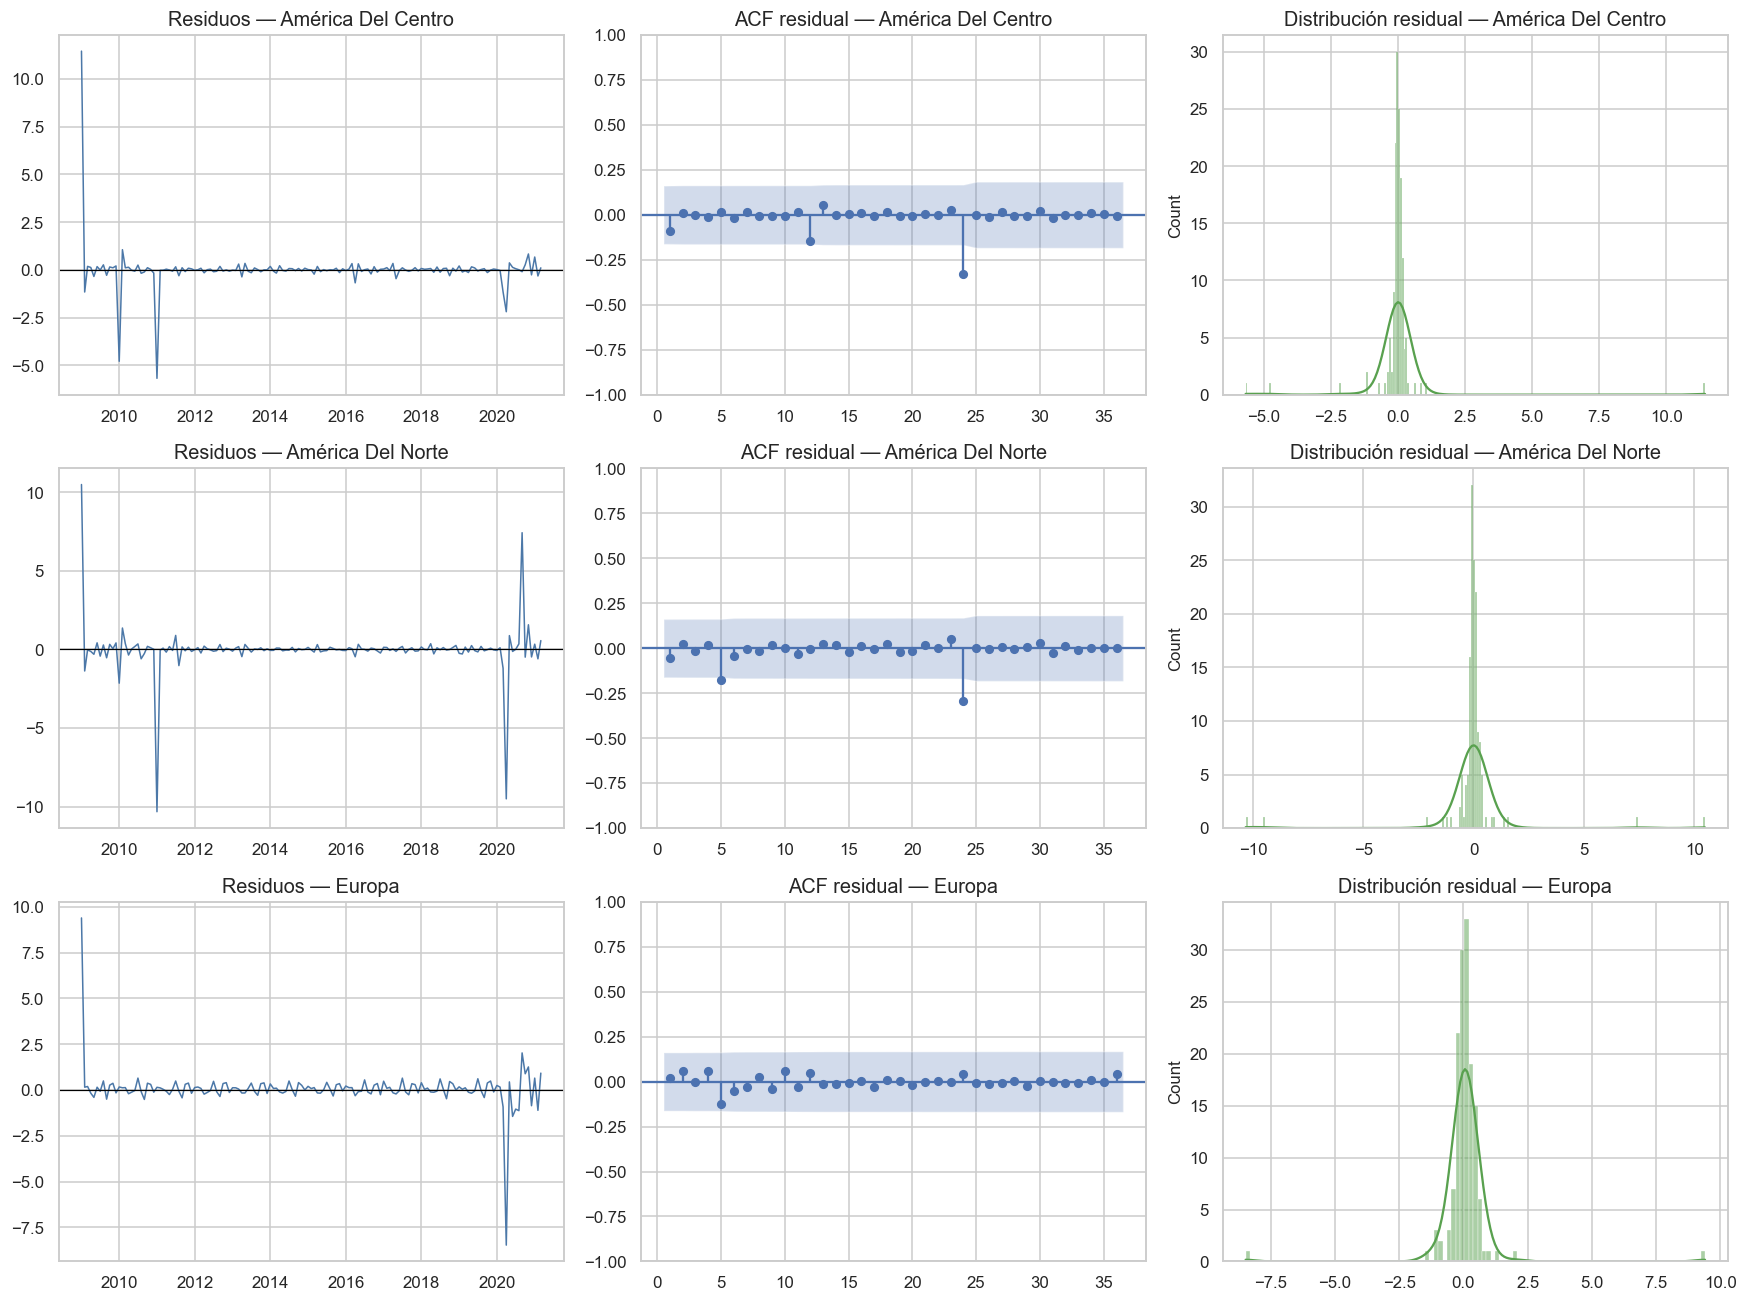

In [23]:
# Inciso: 4(g) — Selección y residuos
mejor_arima = {}
seleccion_arima = []

for region in top3_regiones:
    candidatos = comparacion_arima.loc[
        (comparacion_arima["Región"] == region)
        & comparacion_arima["BIC"].notna()
        & comparacion_arima["Convergió"]
    ].copy()

    residuos_adecuados = candidatos.loc[
        candidatos["Ljung-Box p(12)"] > 0.05
    ]
    elegibles = residuos_adecuados if not residuos_adecuados.empty else candidatos
    fila = elegibles.sort_values("BIC").iloc[0]

    mejor_arima[region] = (
        fila["Modelo"],
        ajustes_arima[region][fila["Modelo"]]
    )
    seleccion_arima.append(fila)

seleccion_arima = pd.DataFrame(seleccion_arima).set_index("Región")
display(seleccion_arima)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for fila, region in enumerate(top3_regiones):
    nombre, ajuste = mejor_arima[region]
    residuo = ajuste.resid.dropna()

    axes[fila, 0].plot(residuo, color="#4C78A8", lw=1)
    axes[fila, 0].axhline(0, color="black", lw=0.8)
    axes[fila, 0].set_title(f"Residuos — {region}")

    plot_acf(
        residuo, lags=min(36, len(residuo) // 2 - 1),
        zero=False, ax=axes[fila, 1]
    )
    axes[fila, 1].set_title(f"ACF residual — {region}")

    sns.histplot(residuo, kde=True, ax=axes[fila, 2], color="#59A14F")
    axes[fila, 2].set_title(f"Distribución residual — {region}")

plt.tight_layout()
plt.show()

In [24]:
# Inciso: 4(f) y 4(g) — Respuesta por región
for region in top3_regiones:
    fila = seleccion_arima.loc[region]
    criterio_residuos = (
        "no muestra autocorrelación significativa al rezago 12"
        if fila["Ljung-Box p(12)"] > 0.05
        else "todavía conserva autocorrelación residual al rezago 12"
    )
    display(Markdown(
        f"- **{region}:** se selecciona **{fila['Modelo']}** con "
        f"AIC={fila['AIC']:.2f}, BIC={fila['BIC']:.2f}. La prueba Ljung-Box "
        f"produce p={fila['Ljung-Box p(12)']:.3f}; el modelo "
        f"{criterio_residuos}. La selección prioriza el menor BIC entre los "
        f"modelos convergentes con residuos aceptables."
    ))

- **América Del Centro:** se selecciona **SARIMA(1, 1, 1)x(1, 1, 0, 12)** con AIC=50.59, BIC=61.78. La prueba Ljung-Box produce p=0.842; el modelo no muestra autocorrelación significativa al rezago 12. La selección prioriza el menor BIC entre los modelos convergentes con residuos aceptables.

- **América Del Norte:** se selecciona **SARIMA(1, 1, 1)x(1, 1, 0, 12)** con AIC=382.00, BIC=393.18. La prueba Ljung-Box produce p=0.748; el modelo no muestra autocorrelación significativa al rezago 12. La selección prioriza el menor BIC entre los modelos convergentes con residuos aceptables.

- **Europa:** se selecciona **ARIMA(1, 0, 1)** con AIC=360.86, BIC=372.76. La prueba Ljung-Box produce p=0.866; el modelo no muestra autocorrelación significativa al rezago 12. La selección prioriza el menor BIC entre los modelos convergentes con residuos aceptables.

### Inciso: 4(h)–4(k) — Modelos alternativos y pronóstico

### Modelos alternativos y pronóstico

Se comparan cinco enfoques en el conjunto de prueba:

- El mejor ARIMA/SARIMA según entrenamiento.
- Prophet con tendencia flexible y estacionalidad anual.
- Holt-Winters con tendencia amortiguada y estacionalidad aditiva.
- Suavizamiento exponencial simple, que proyecta un nivel suavizado.
- Seasonal naïve, que repite el valor del mismo mes del último año.

MAE conserva las unidades originales y mide el error absoluto medio. RMSE penaliza con mayor fuerza los errores grandes.

In [25]:
# Inciso: 4(h), 4(i) y 4(j) — Ajuste, predicción y métricas
def metricas_error(real, predicho):
    real = np.asarray(real, dtype=float)
    predicho = np.asarray(predicho, dtype=float)
    return {
        "MAE": mean_absolute_error(real, predicho),
        "RMSE": np.sqrt(mean_squared_error(real, predicho))
    }


predicciones = {}
metricas_modelos = []

for region in top3_regiones:
    y_train = series_region_train[region].astype(float)
    y_test = series_region_test[region].astype(float)
    y_log = np.log1p(y_train)
    predicciones[region] = {}

    nombre_arima_elegido, ajuste_arima = mejor_arima[region]
    pred_arima = np.expm1(
        ajuste_arima.get_forecast(steps=len(y_test)).predicted_mean
    ).clip(lower=0)
    pred_arima.index = y_test.index
    predicciones[region]["ARIMA/SARIMA"] = pred_arima

    prophet_df = pd.DataFrame({"ds": y_train.index, "y": y_log.values})
    modelo_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=0.10,
        interval_width=0.95
    )
    modelo_prophet.fit(prophet_df)
    futuro = pd.DataFrame({"ds": y_test.index})
    pred_prophet = pd.Series(
        np.expm1(modelo_prophet.predict(futuro)["yhat"].values),
        index=y_test.index
    ).clip(lower=0)
    predicciones[region]["Prophet"] = pred_prophet

    modelo_hw = ExponentialSmoothing(
        y_log,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    ).fit(optimized=True, use_brute=True)
    pred_hw = pd.Series(
        np.expm1(modelo_hw.forecast(len(y_test)).values),
        index=y_test.index
    ).clip(lower=0)
    predicciones[region]["Holt-Winters"] = pred_hw

    modelo_ses = SimpleExpSmoothing(
        y_log, initialization_method="estimated"
    ).fit(optimized=True)
    pred_ses = pd.Series(
        np.expm1(modelo_ses.forecast(len(y_test)).values),
        index=y_test.index
    ).clip(lower=0)
    predicciones[region]["Suavizamiento exponencial"] = pred_ses

    patron_anual = y_train.iloc[-12:].values
    pred_naive = pd.Series(
        np.resize(patron_anual, len(y_test)),
        index=y_test.index
    )
    predicciones[region]["Seasonal naïve"] = pred_naive

    for modelo, predicho in predicciones[region].items():
        errores = metricas_error(y_test, predicho)
        metricas_modelos.append({
            "Región": region,
            "Modelo": modelo,
            **errores,
            "AIC": (
                seleccion_arima.loc[region, "AIC"]
                if modelo == "ARIMA/SARIMA" else np.nan
            ),
            "BIC": (
                seleccion_arima.loc[region, "BIC"]
                if modelo == "ARIMA/SARIMA" else np.nan
            )
        })

metricas_modelos = pd.DataFrame(metricas_modelos)
metricas_modelos["Rango RMSE"] = (
    metricas_modelos.groupby("Región")["RMSE"]
                    .rank(method="min")
                    .astype(int)
)
display(
    metricas_modelos.sort_values(["Región", "RMSE"])
        .set_index(["Región", "Modelo"])
)

MAE  \
Región             Modelo                                                        
América Del Centro Suavizamiento exponencial                        108,284.61   
                   Holt-Winters                                     113,415.13   
                   Seasonal naïve                                   134,400.18   
                   ARIMA/SARIMA                                     150,583.63   
                   Prophet                                          156,597.28   
América Del Norte  Suavizamiento exponencial                         32,193.83   
                   Holt-Winters                                      40,796.87   
                   Seasonal naïve                                    49,974.11   
                   Prophet                                           55,626.13   
                   ARIMA/SARIMA              56,909,375,132,873,330,262,016.00   
Europa             ARIMA/SARIMA                                       6,420.06   
                   Suavizamiento exponencial                          9,291.88   
                   Holt-Winters                                      10,377.75   
                   Seasonal naïve                                    11,075.47   
                   Prophet                                           11,675.78   

                                                                           RMSE  \
Región             Modelo                                                         
América Del Centro Suavizamiento exponencial                         120,341.06   
                   Holt-Winters                                      124,213.76   
                   Seasonal naïve                                    144,899.30   
                   ARIMA/SARIMA                                      163,920.41   
                   Prophet                                           166,856.62   
América Del Norte  Suavizamiento exponencial                          36,725.47   
                   Holt-Winters                                       44,975.55   
                   Seasonal naïve                                     53,533.37   
                   Prophet                                            59,243.61   
                   ARIMA/SARIMA              262,916,278,719,193,093,767,168.00   
Europa             ARIMA/SARIMA                                        7,823.86   
                   Suavizamiento exponencial                          10,694.58   
                   Holt-Winters                                       11,563.43   
                   Seasonal naïve                                     12,134.51   
                   Prophet                                            12,887.19   

                                                AIC    BIC  Rango RMSE  
Región             Modelo                                               
América Del Centro Suavizamiento exponencial    NaN    NaN           1  
                   Holt-Winters                 NaN    NaN           2  
                   Seasonal naïve               NaN    NaN           3  
                   ARIMA/SARIMA               50.59  61.78           4  
                   Prophet                      NaN    NaN           5  
América Del Norte  Suavizamiento exponencial    NaN    NaN           1  
                   Holt-Winters                 NaN    NaN           2  
                   Seasonal naïve               NaN    NaN           3  
                   Prophet                      NaN    NaN           4  
                   ARIMA/SARIMA              382.00 393.18           5  
Europa             ARIMA/SARIMA              360.86 372.76           1  
                   Suavizamiento exponencial    NaN    NaN           2  
                   Holt-Winters                 NaN    NaN           3  
                   Seasonal naïve               NaN    NaN           4  
                   Prophet                      NaN    NaN           5

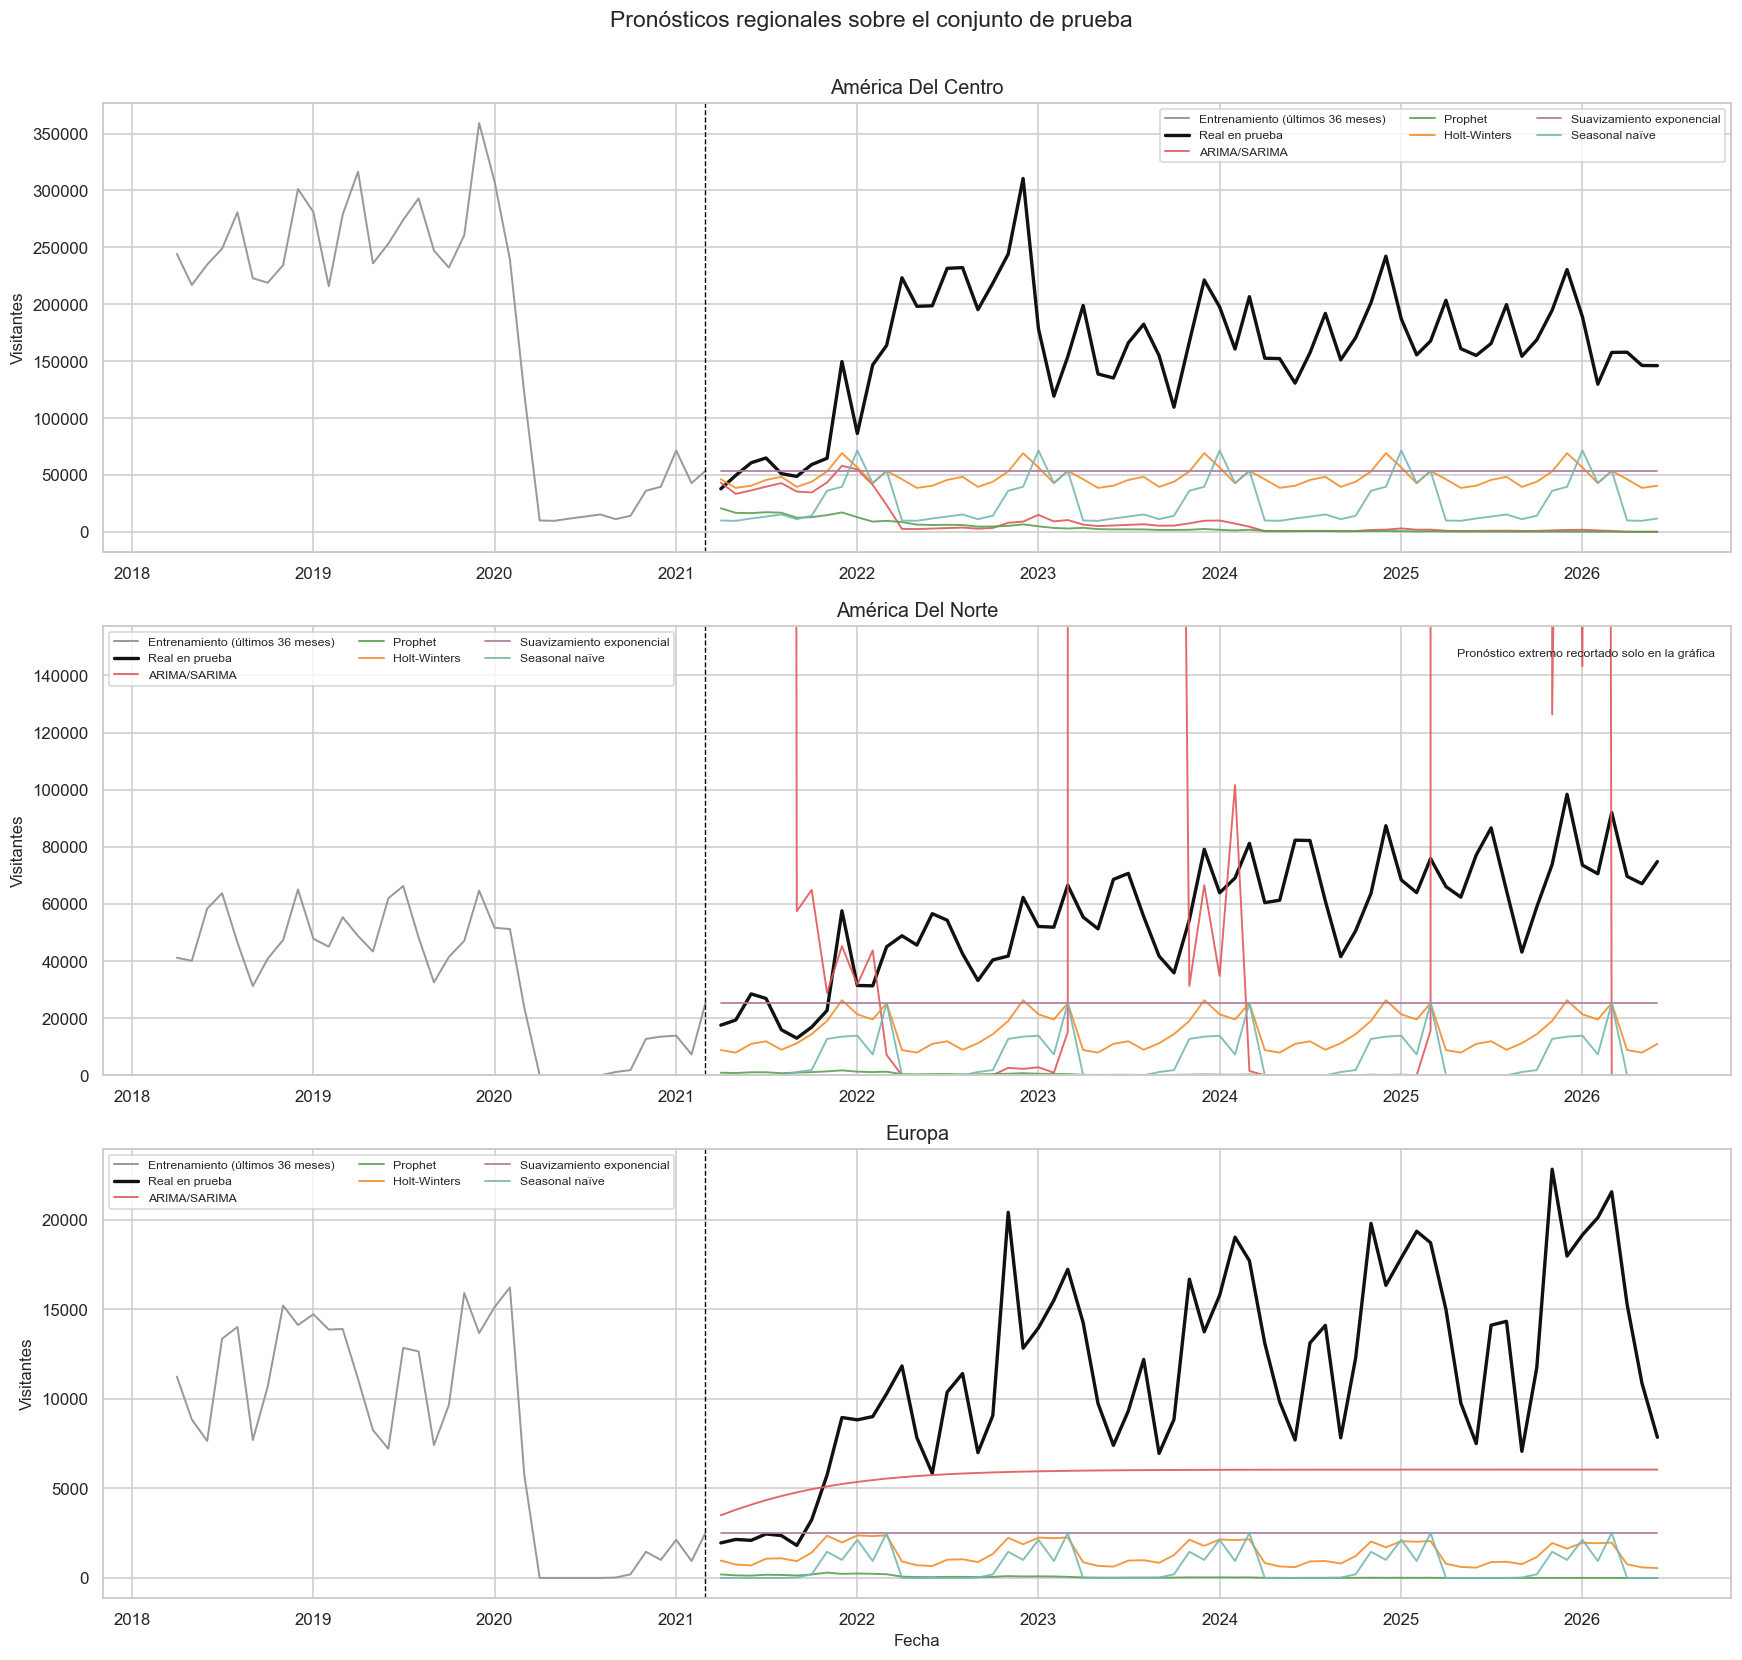

In [26]:
# Inciso: 4(i) — Gráfico de pronósticos
fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=False)
paleta = {
    "ARIMA/SARIMA": "#E15759",
    "Prophet": "#59A14F",
    "Holt-Winters": "#F28E2B",
    "Suavizamiento exponencial": "#B07AA1",
    "Seasonal naïve": "#76B7B2"
}

for ax, region in zip(axes, top3_regiones):
    observado_train = series_region_train[region].iloc[-36:]
    observado_test = series_region_test[region]

    ax.plot(
        observado_train, color="#999999", lw=1.3,
        label="Entrenamiento (últimos 36 meses)"
    )
    ax.plot(
        observado_test, color="#111111", lw=2.2,
        label="Real en prueba"
    )
    for modelo, predicho in predicciones[region].items():
        ax.plot(
            predicho, lw=1.25, alpha=0.9,
            color=paleta[modelo], label=modelo
        )
    limite_grafico = 1.6 * max(observado_train.max(), observado_test.max())
    if max(pred.max() for pred in predicciones[region].values()) > limite_grafico:
        ax.set_ylim(0, limite_grafico)
        ax.text(0.99, 0.95, "Pronóstico extremo recortado solo en la gráfica",
                transform=ax.transAxes, ha="right", va="top", fontsize=8)
    ax.axvline(fecha_corte, color="black", ls="--", lw=0.9)
    ax.set_title(region)
    ax.set_ylabel("Visitantes")
    ax.legend(ncol=3, fontsize=8)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Pronósticos regionales sobre el conjunto de prueba", y=1.005, fontsize=15)
plt.tight_layout()
plt.show()

In [27]:
# Inciso: 4(j) y 4(k) — Comparación y mejor modelo
mejores_modelos = (
    metricas_modelos.sort_values(["Región", "RMSE", "MAE"])
                    .drop_duplicates("Región")
                    .set_index("Región")
)
display(mejores_modelos)

for region in top3_regiones:
    mejor = mejores_modelos.loc[region]
    arima = seleccion_arima.loc[region]
    razon_extrema = predicciones[region]["ARIMA/SARIMA"].max() / max(series_region_test[region].max(), 1)
    advertencia = (
        " La proyección ARIMA/SARIMA es explosiva fuera de muestra y se descarta, "
        "aunque sus diagnósticos internos sean aceptables."
        if razon_extrema > 10 else ""
    )
    display(Markdown(
        f"**{region}.** El mejor pronóstico fuera de muestra es "
        f"**{mejor['Modelo']}**, con MAE={mejor['MAE']:,.0f} visitantes y "
        f"RMSE={mejor['RMSE']:,.0f}. Para la familia ARIMA, "
        f"**{arima['Modelo']}** fue la estructura preferida con "
        f"AIC={arima['AIC']:.2f} y BIC={arima['BIC']:.2f}. "
        f"AIC y BIC no se usan para ordenar Prophet, Holt-Winters, "
        f"suavizamiento exponencial y seasonal naïve porque no comparten la "
        f"misma función de verosimilitud ni parametrización.{advertencia}"
    ))

,Modelo,MAE,RMSE,AIC,BIC,Rango RMSE
Región,,,,,,
América Del Centro,Suavizamiento exponencial,"108,284.61","120,341.06",NaN,NaN,1
América Del Norte,Suavizamiento exponencial,"32,193.83","36,725.47",NaN,NaN,1
Europa,ARIMA/SARIMA,"6,420.06","7,823.86",360.86,372.76,1


**América Del Centro.** El mejor pronóstico fuera de muestra es **Suavizamiento exponencial**, con MAE=108,285 visitantes y RMSE=120,341. Para la familia ARIMA, **SARIMA(1, 1, 1)x(1, 1, 0, 12)** fue la estructura preferida con AIC=50.59 y BIC=61.78. AIC y BIC no se usan para ordenar Prophet, Holt-Winters, suavizamiento exponencial y seasonal naïve porque no comparten la misma función de verosimilitud ni parametrización.

**América Del Norte.** El mejor pronóstico fuera de muestra es **Suavizamiento exponencial**, con MAE=32,194 visitantes y RMSE=36,725. Para la familia ARIMA, **SARIMA(1, 1, 1)x(1, 1, 0, 12)** fue la estructura preferida con AIC=382.00 y BIC=393.18. AIC y BIC no se usan para ordenar Prophet, Holt-Winters, suavizamiento exponencial y seasonal naïve porque no comparten la misma función de verosimilitud ni parametrización. La proyección ARIMA/SARIMA es explosiva fuera de muestra y se descarta, aunque sus diagnósticos internos sean aceptables.

**Europa.** El mejor pronóstico fuera de muestra es **ARIMA/SARIMA**, con MAE=6,420 visitantes y RMSE=7,824. Para la familia ARIMA, **ARIMA(1, 0, 1)** fue la estructura preferida con AIC=360.86 y BIC=372.76. AIC y BIC no se usan para ordenar Prophet, Holt-Winters, suavizamiento exponencial y seasonal naïve porque no comparten la misma función de verosimilitud ni parametrización.

### Inciso: 4(i)–4(k) — Interpretación predictiva

El horizonte de prueba inicia durante una ruptura histórica y contiene la recuperación posterior. Por ello, los errores no representan únicamente ruido de pronóstico: también miden cuánto puede adaptarse cada algoritmo a un nivel que no estaba plenamente observado al final del entrenamiento. La selección final se basa primero en RMSE y, en caso de resultados cercanos, en MAE y simplicidad.

### Inciso: 5(a) — Comparación estadística regional

## 12. Comparación estadística entre regiones

Para evitar que la pandemia distorsione la estacionalidad y el crecimiento estructural, estas dos características se estiman con enero de 2009 a diciembre de 2019. La volatilidad usa la desviación de los cambios interanuales mensuales en ese mismo período. El impacto pandémico compara los totales de 2020 y 2019, la recuperación compara 2024 con 2019.

In [28]:
# Inciso: 5(a-i)–5(a-iv) — Evidencia comparativa
prepandemia = series_region_full.loc["2009-01":"2019-12"]
comparacion_regional = []

for region in top3_regiones:
    serie_pre = prepandemia[region]
    descomp_pre = seasonal_decompose(
        serie_pre, model="additive", period=12, extrapolate_trend="freq"
    )
    _, fuerza_estacional_pre = fuerza_componentes(descomp_pre)
    anual_region = series_region_full[region].resample("YS").sum()
    anual_region.index = anual_region.index.year
    crecimiento_cagr = (
        (anual_region.loc[2019] / anual_region.loc[2009]) ** (1 / 10) - 1
    )
    cambio_interanual = serie_pre.pct_change(12).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()

    comparacion_regional.append({
        "Región": region,
        "Fuerza estacional pre-2020": fuerza_estacional_pre,
        "Crecimiento anual compuesto 2009-2019 (%)": 100 * crecimiento_cagr,
        "Volatilidad interanual pre-2020 (desv. %)": 100 * cambio_interanual.std(),
        "Impacto 2020 vs 2019 (%)": (
            100 * (anual_region.loc[2020] / anual_region.loc[2019] - 1)
        ),
        "Recuperación 2024 vs 2019 (%)": (
            100 * (anual_region.loc[2024] / anual_region.loc[2019] - 1)
        )
    })

comparacion_regional = pd.DataFrame(comparacion_regional).set_index("Región")
display(comparacion_regional)

,Fuerza estacional pre-2020,Crecimiento anual compuesto 2009-2019 (%),Volatilidad interanual pre-2020 (desv. %),Impacto 2020 vs 2019 (%),Recuperación 2024 vs 2019 (%)
Región,,,,,
América Del Centro,0.69,9.83,14.49,-74.43,-34.87
América Del Norte,0.89,3.81,11.98,-74.14,33.56
Europa,0.88,2.33,12.74,-71.83,17.98


In [29]:
# Inciso: 5(a-i)–5(a-iv) — Respuestas comparativas
ganadora_estacionalidad = comparacion_regional[
    "Fuerza estacional pre-2020"
].idxmax()
ganadora_crecimiento = comparacion_regional[
    "Crecimiento anual compuesto 2009-2019 (%)"
].idxmax()
ganadora_volatilidad = comparacion_regional[
    "Volatilidad interanual pre-2020 (desv. %)"
].idxmax()
mas_afectada = comparacion_regional[
    "Impacto 2020 vs 2019 (%)"
].idxmin()

display(Markdown(
    f"""
### Respuestas comparativas

- **Mayor estacionalidad:** **{ganadora_estacionalidad}**, con una fuerza estacional pre-2020 de {comparacion_regional.loc[ganadora_estacionalidad, "Fuerza estacional pre-2020"]:.3f}.
- **Mayor tendencia de crecimiento:** **{ganadora_crecimiento}**, con crecimiento anual compuesto de {comparacion_regional.loc[ganadora_crecimiento, "Crecimiento anual compuesto 2009-2019 (%)"]:.2f}% entre 2009 y 2019.
- **Mayor volatilidad:** **{ganadora_volatilidad}**, cuya desviación estándar de cambios interanuales mensuales fue {comparacion_regional.loc[ganadora_volatilidad, "Volatilidad interanual pre-2020 (desv. %)"]:.2f}% antes de la pandemia.
- **Mayor afectación por la pandemia:** **{mas_afectada}**, con una variación de {comparacion_regional.loc[mas_afectada, "Impacto 2020 vs 2019 (%)"]:.2f}% entre 2019 y 2020.
"""
))


### Respuestas comparativas

- **Mayor estacionalidad:** **América Del Norte**, con una fuerza estacional pre-2020 de 0.893.
- **Mayor tendencia de crecimiento:** **América Del Centro**, con crecimiento anual compuesto de 9.83% entre 2009 y 2019.
- **Mayor volatilidad:** **América Del Centro**, cuya desviación estándar de cambios interanuales mensuales fue 14.49% antes de la pandemia.
- **Mayor afectación por la pandemia:** **América Del Centro**, con una variación de -74.43% entre 2019 y 2020.


### Inciso: 5(b-i) — Implicaciones para INGUAT

### Implicaciones para la toma de decisiones

- La concentración regional exige estrategias diferenciadas: Centroamérica depende de conectividad terrestre, mientras que Norteamérica y Europa requieren capacidad aérea y coordinación con aerolíneas.
- Los meses estacionalmente altos permiten anticipar personal, señalización, transporte y capacidad en puntos de entrada, los meses bajos son adecuados para mantenimiento y campañas que reduzcan la estacionalidad.
- La recuperación no debe evaluarse solo con tasas de crecimiento posteriores a 2020. El índice frente a 2019 distingue recuperación real de un rebote desde una base excepcionalmente baja.
- Los escenarios de planificación deben incorporar rupturas estructurales. Un modelo entrenado antes o durante la pandemia no puede extrapolar automáticamente la velocidad de reapertura.
- MAE ofrece una estimación directa del error operativo esperado, RMSE identifica modelos vulnerables a errores mensuales grandes. Conviene monitorear ambas métricas y reentrenar conforme se incorporen nuevos meses.
- Las proyecciones regionales permiten dirigir promoción y conectividad hacia la región con mayor crecimiento, mientras se diseñan medidas de resiliencia para la región más volátil o más expuesta a interrupciones.

### Inciso: 4(k) y 5(b-i) — Conclusión regional

## Conclusión regional

Las tres series requieren tratamiento explícito de tendencia, estacionalidad anual, varianza cambiante y ruptura pandémica. La transformación logarítmica y las diferencias determinadas mediante ADF producen una base más adecuada para ARIMA/SARIMA. La comparación fuera de muestra muestra qué algoritmo se adapta mejor a cada región, no existe obligación estadística de usar un único modelo para todas. La elección final debe actualizarse periódicamente porque el período de prueba contiene una recuperación estructural que modifica los niveles históricos.

## Informe de resultados (documento completo)

# Análisis de series de tiempo por regiones geográficas

## 1. Introducción

Este informe presenta el análisis de las tres regiones geográficas con mayor volumen acumulado de visitantes internacionales a Guatemala:

- América Del Centro
- América Del Norte
- Europa

Las regiones fueron seleccionadas de acuerdo con el total acumulado de todo el período disponible, no a partir de un año particular. Para mantener comparabilidad temporal se consideraron únicamente las categorías Turista y Excursionista. La categoría Viajero presenta un cambio metodológico desde 2023 y los cruceristas dejaron de registrarse en esta fuente a partir de ese año, por lo que incluirlos habría introducido cambios de medición ajenos al comportamiento turístico.

El período completo comprende enero de 2009 a junio de 2026. La división se realizó respetando el orden temporal, con el 70 % inicial para entrenamiento y el 30 % final para prueba. De esta manera no se utilizó información futura para estimar los modelos.

## 2. Cobertura de las series

**Tabla 1. Cobertura temporal de las series regionales**

| Región | Inicio de entrenamiento | Fin de entrenamiento | Inicio de prueba | Fin de prueba | Frecuencia | Meses de entrenamiento | Meses de prueba | Meses faltantes |
|---|---:|---:|---:|---:|---|---:|---:|---:|
| América Del Centro | 2009-01 | 2021-03 | 2021-04 | 2026-06 | Mensual | 147 | 63 | 0 |
| América Del Norte | 2009-01 | 2021-03 | 2021-04 | 2026-06 | Mensual | 147 | 63 | 0 |
| Europa | 2009-01 | 2021-03 | 2021-04 | 2026-06 | Mensual | 147 | 63 | 0 |

La Tabla 1 muestra que las tres series tienen la misma cobertura, frecuencia mensual y ausencia de meses faltantes. Esta estructura permite realizar comparaciones directas entre regiones. El conjunto de entrenamiento termina en marzo de 2021 y el de prueba comienza en abril de 2021, por lo que una parte considerable de la recuperación posterior a la pandemia queda fuera del período utilizado para ajustar los modelos.

**Figura 1. Comportamiento mensual de las tres regiones geográficas**

![Comportamiento mensual de las tres regiones](informe_regiones_assets/figura_1_series_regionales.png)

La Figura 1 muestra un crecimiento sostenido antes de 2020, oscilaciones que se repiten dentro de cada año y una caída extraordinaria desde marzo de 2020. La línea suavizada corresponde a la media móvil de doce meses. Esta media permite observar el cambio de nivel de largo plazo sin que las variaciones mensuales oculten la tendencia.

América Del Centro presenta el mayor volumen y una fuerte relación con el ingreso terrestre. América Del Norte y Europa tienen menores niveles, pero una mayor dependencia de la conectividad aérea. En las tres series la caída de 2020 representa una ruptura estructural y no una fluctuación estacional normal.

## 3. Descomposición de las series

Las series se descompusieron en cuatro elementos:

- Serie observada
- Tendencia
- Estacionalidad anual
- Residuo

Se utilizó una periodicidad de doce meses. La fuerza de tendencia y la fuerza de estacionalidad toman valores entre cero y uno. Un valor alto indica que el componente explica una proporción importante de la variación frente al residuo.

**Tabla 2. Fuerza de los componentes durante el período de entrenamiento**

| Región | Fuerza de tendencia | Fuerza de estacionalidad | Mes estacional máximo | Mes estacional mínimo |
|---|---:|---:|---:|---:|
| América Del Centro | 0.77 | 0.36 | Diciembre | Septiembre |
| América Del Norte | 0.64 | 0.57 | Diciembre | Septiembre |
| Europa | 0.81 | 0.76 | Febrero | Junio |

La Tabla 2 indica que Europa presenta la mayor fuerza de tendencia, con 0.81, y la mayor fuerza estacional dentro del entrenamiento, con 0.76. América Del Centro también tiene una tendencia importante, pero su patrón estacional aparece menos regular debido a la magnitud del choque ocurrido en 2020. América Del Norte ocupa una posición intermedia.

El mes estacional más fuerte para América Del Centro y América Del Norte es diciembre, mientras que el valor mínimo se observa en septiembre. Europa alcanza su componente estacional máximo en febrero y el mínimo en junio.

**Figura 2. Descomposición de América Del Centro**

![Descomposición de América Del Centro](informe_regiones_assets/figura_2_descomposicion_centro.png)

En América Del Centro se observa un crecimiento pronunciado antes de 2020. La caída pandémica se refleja principalmente en la tendencia y en el residuo, porque no corresponde a una variación que se repita cada año.

**Figura 3. Descomposición de América Del Norte**

![Descomposición de América Del Norte](informe_regiones_assets/figura_3_descomposicion_norte.png)

América Del Norte presenta una tendencia creciente más moderada y un ciclo anual más claro que América Del Centro. El residuo aumenta de forma considerable durante la ruptura de 2020.

**Figura 4. Descomposición de Europa**

![Descomposición de Europa](informe_regiones_assets/figura_4_descomposicion_europa.png)

Europa muestra el patrón estacional más regular dentro del entrenamiento y una tendencia claramente cambiante. Al igual que en las otras regiones, la pandemia produce una desviación que no puede explicarse mediante la estacionalidad normal.

## 4. Estacionariedad en varianza y transformación

Una serie estacionaria en varianza mantiene una dispersión aproximadamente constante en el tiempo. Para estudiar esta condición se comparó la media móvil con la desviación estándar móvil, se calculó el coeficiente de variación de cada mitad del entrenamiento y se estimó el parámetro de Box-Cox.

**Tabla 3. Diagnóstico de estabilidad de la varianza**

| Región | Correlación entre media y desviación móvil | Lambda Box-Cox | CV primera mitad | CV segunda mitad | Escala utilizada para modelar |
|---|---:|---:|---:|---:|---|
| América Del Centro | 0.15 | 0.88 | 0.24 | 0.46 | log(1+x) |
| América Del Norte | -0.34 | 1.53 | 0.22 | 0.45 | log(1+x) |
| Europa | -0.23 | 1.68 | 0.23 | 0.49 | log(1+x) |

La relación entre la media y la desviación móvil es débil. Además, los parámetros de Box-Cox no se aproximan a cero. Por ello no existe evidencia suficiente para afirmar que la transformación logarítmica sea estrictamente necesaria para estabilizar la varianza.

Sin embargo, los coeficientes de variación son claramente mayores en la segunda mitad, principalmente por la ruptura de 2020. Se utilizó la transformación log(1+x) como decisión conservadora de modelado, porque reduce la influencia de los valores extremos, representa cambios relativos y permite regresar a una escala no negativa. Esta decisión no equivale a afirmar que la varianza obligaba a transformar.

**Figura 5. Comparación entre las series originales y la transformación logarítmica**

![Diagnóstico de varianza y transformación](informe_regiones_assets/figura_5_varianza_transformacion.png)

La Figura 5 permite observar que la transformación comprime las diferencias de escala y reduce el dominio visual de los valores más altos. La ruptura pandémica sigue siendo visible, pero su magnitud relativa resulta más manejable para el ajuste estadístico.

## 5. Estacionariedad en media

La estacionariedad en media implica que el nivel esperado de la serie no cambia sistemáticamente con el tiempo. Se utilizaron dos fuentes de evidencia:

1. La función de autocorrelación, que permite observar si la dependencia con los valores anteriores desaparece rápidamente o permanece durante varios rezagos.
2. La prueba Dickey-Fuller aumentada, cuya hipótesis nula establece que existe una raíz unitaria. Un valor p menor que 0.05 permite rechazar esa hipótesis.

**Tabla 4. Resultados principales de la prueba Dickey-Fuller aumentada**

| Región | p en nivel | p en log(1+x) | p con primera diferencia | p con diferencia estacional | p con ambas diferencias | d | D |
|---|---:|---:|---:|---:|---:|---:|---:|
| América Del Centro | 0.21 | 0.20 | 0.04 | 0.97 | <0.001 | 1 | 1 |
| América Del Norte | 0.01 | 0.16 | 0.05 | 0.94 | <0.001 | 1 | 1 |
| Europa | 0.12 | 0.28 | 0.11 | <0.001 | <0.001 | 0 | 1 |

Las decisiones se tomaron sobre la escala log(1+x), que es la utilizada en los modelos. Aunque América Del Norte presenta un valor p bajo en la escala original, deja de rechazar la raíz unitaria después de aplicar el logaritmo. Por esta razón se estudió la diferenciación sobre la escala transformada.

**Tabla 5. Persistencia de la autocorrelación y diferenciación aplicada**

| Región | ACF rezago 1 | ACF rezago 3 | ACF rezago 6 | p de ADF en log-nivel | d | D | p después de diferenciar |
|---|---:|---:|---:|---:|---:|---:|---:|
| América Del Centro | 0.88 | 0.67 | 0.35 | 0.20 | 1 | 1 | <0.001 |
| América Del Norte | 0.85 | 0.51 | 0.09 | 0.16 | 1 | 1 | <0.001 |
| Europa | 0.89 | 0.58 | 0.17 | 0.28 | 0 | 1 | <0.001 |

### 5.1 América Del Centro

La autocorrelación comienza en 0.88 en el primer rezago y disminuye gradualmente hasta 0.35 en el sexto. Esta persistencia indica que el nivel de cada mes depende fuertemente de los meses anteriores y que la media no permanece constante. El valor p de 0.20 en el log-nivel confirma que no se puede rechazar la raíz unitaria.

Una primera diferencia ordinaria reduce el valor p a 0.04, por lo que resulta suficiente para obtener estacionariedad en media. También se utilizó una diferencia estacional de doce meses para eliminar el patrón anual. En consecuencia se evaluaron modelos con d igual a uno y D igual a uno.

### 5.2 América Del Norte

La autocorrelación del primer rezago es 0.85 y disminuye a través de los siguientes rezagos. Este comportamiento muestra persistencia temporal. El valor p del log-nivel es 0.16 y no permite rechazar la raíz unitaria.

La primera diferencia se encuentra aproximadamente en el límite de 0.05. La combinación de una diferencia ordinaria y una diferencia estacional rechaza claramente la raíz unitaria. Por ello se utilizaron d igual a uno y D igual a uno.

### 5.3 Europa

Europa presenta una autocorrelación de 0.89 en el primer rezago y una disminución gradual. El valor p del log-nivel es 0.28. Una primera diferencia ordinaria todavía produce un valor p de 0.11, por lo que esa transformación no es suficiente.

La diferencia estacional de doce meses produce un valor p menor que 0.001. Por tanto, Europa necesita D igual a uno, pero no una diferencia ordinaria adicional. El valor de d seleccionado fue cero.

**Figura 6. ACF en nivel, ACF transformada y PACF transformada**

![Funciones ACF y PACF de las regiones](informe_regiones_assets/figura_6_acf_pacf.png)

La primera columna de la Figura 6 muestra la ACF del log-nivel. Las autocorrelaciones iniciales altas y su disminución gradual aportan evidencia visual de una media cambiante. La segunda y tercera columnas muestran la ACF y PACF después de diferenciar. La persistencia prolongada desaparece y los valores p de ADF quedan por debajo de 0.05.

## 6. Selección de los modelos ARIMA y SARIMA

Los valores de p y q se exploraron entre cero y dos. Los primeros rezagos de ACF y PACF justificaron usar órdenes pequeños y parsimoniosos. También se evaluaron términos estacionales con periodicidad doce.

Los modelos se compararon utilizando AIC, BIC y la prueba de Ljung-Box sobre los residuos. AIC y BIC favorecen un buen ajuste con penalización por complejidad. Para Ljung-Box, un valor p superior a 0.05 indica que no existe evidencia de autocorrelación residual significativa en el rezago evaluado.

**Tabla 6. Modelos ARIMA o SARIMA seleccionados con el conjunto de entrenamiento**

| Región | Modelo seleccionado | AIC | BIC | p de Ljung-Box en rezago 12 | Convergió |
|---|---|---:|---:|---:|---|
| América Del Centro | SARIMA(1,1,1)(1,1,0)[12] | 50.59 | 61.78 | 0.84 | Sí |
| América Del Norte | SARIMA(1,1,1)(1,1,0)[12] | 382.00 | 393.18 | 0.75 | Sí |
| Europa | ARIMA(1,0,1) | 360.86 | 372.76 | 0.87 | Sí |

Para América Del Centro se seleccionó SARIMA(1,1,1)(1,1,0)[12]. Su valor p de Ljung-Box fue 0.84, por lo que los residuos no mostraron dependencia serial significativa.

En América Del Norte se seleccionó la misma estructura estacional. El valor p de Ljung-Box fue 0.75. No obstante, durante la evaluación fuera de muestra el modelo produjo una trayectoria explosiva. Este resultado demuestra que buenos diagnósticos dentro del entrenamiento no garantizan estabilidad en un horizonte largo que contiene un cambio estructural.

Para Europa se eligió ARIMA(1,0,1). Algunos candidatos estacionales presentaron menores valores de BIC, pero conservaron autocorrelación residual significativa. El modelo ARIMA seleccionado alcanzó un valor p de Ljung-Box de 0.87 y produjo el mejor desempeño predictivo para esta región.

**Figura 7. Diagnóstico de los residuos de los modelos seleccionados**

![Diagnóstico de residuos](informe_regiones_assets/figura_7_residuos.png)

La Figura 7 muestra la trayectoria temporal, la autocorrelación y la distribución de los residuos. Los valores de Ljung-Box superiores a 0.05 respaldan que los modelos seleccionados no dejan una estructura temporal clara sin explicar dentro del entrenamiento.

## 7. Comparación de métodos y predicción

Para cada región se compararon cinco enfoques:

- Mejor ARIMA o SARIMA seleccionado con entrenamiento
- Prophet
- Holt-Winters con tendencia amortiguada y estacionalidad anual
- Suavizamiento exponencial simple
- Seasonal naïve

La comparación fuera de muestra se realizó con MAE y RMSE. MAE representa el error absoluto promedio en número de visitantes. RMSE penaliza más fuertemente los errores grandes.

Los valores AIC y BIC se presentan únicamente para ARIMA o SARIMA. No es correcto utilizarlos para ordenar todos los algoritmos porque Prophet, Holt-Winters, suavizamiento exponencial y seasonal naïve no comparten la misma función de verosimilitud ni la misma parametrización.

**Tabla 7. Comparación de modelos sobre el conjunto de prueba**

| Región | Modelo | MAE | RMSE | AIC | BIC | Posición por RMSE |
|---|---|---:|---:|---:|---:|---:|
| América Del Centro | Suavizamiento exponencial | 108,285 | 120,341 | — | — | 1 |
| América Del Centro | Holt-Winters | 113,415 | 124,214 | — | — | 2 |
| América Del Centro | Seasonal naïve | 134,400 | 144,899 | — | — | 3 |
| América Del Centro | ARIMA/SARIMA | 150,584 | 163,920 | 50.59 | 61.78 | 4 |
| América Del Centro | Prophet | 156,597 | 166,857 | — | — | 5 |
| América Del Norte | Suavizamiento exponencial | 32,194 | 36,725 | — | — | 1 |
| América Del Norte | Holt-Winters | 40,797 | 44,976 | — | — | 2 |
| América Del Norte | Seasonal naïve | 49,974 | 53,533 | — | — | 3 |
| América Del Norte | Prophet | 55,626 | 59,244 | — | — | 4 |
| América Del Norte | ARIMA/SARIMA | 5.69 × 10²² | 2.63 × 10²³ | 382.00 | 393.18 | 5 |
| Europa | ARIMA/SARIMA | 6,420 | 7,824 | 360.86 | 372.76 | 1 |
| Europa | Suavizamiento exponencial | 9,292 | 10,695 | — | — | 2 |
| Europa | Holt-Winters | 10,378 | 11,563 | — | — | 3 |
| Europa | Seasonal naïve | 11,076 | 12,135 | — | — | 4 |
| Europa | Prophet | 11,676 | 12,887 | — | — | 5 |

**Tabla 8. Mejor modelo predictivo de cada región**

| Región | Mejor modelo | MAE | RMSE |
|---|---|---:|---:|
| América Del Centro | Suavizamiento exponencial | 108,285 | 120,341 |
| América Del Norte | Suavizamiento exponencial | 32,194 | 36,725 |
| Europa | ARIMA(1,0,1) | 6,420 | 7,824 |

El suavizamiento exponencial simple obtuvo los menores errores para América Del Centro y América Del Norte. Su ventaja se explica por el contexto del corte temporal. El entrenamiento termina cerca del período de menor actividad y el conjunto de prueba contiene una recuperación con un nivel distinto. Los modelos con tendencias y componentes más complejos extrapolaron patrones que no representaron adecuadamente la reapertura.

En Europa, ARIMA(1,0,1) obtuvo el menor MAE y RMSE. El modelo capturó mejor la dependencia de corto plazo sin producir la inestabilidad observada en el SARIMA de América Del Norte.

**Figura 8. Pronósticos sobre el conjunto de prueba**

![Pronósticos regionales](informe_regiones_assets/figura_8_pronosticos.png)

La Figura 8 compara los valores reales con los pronósticos. En América Del Norte la proyección SARIMA excede ampliamente la escala de los datos y fue recortada únicamente en la visualización para conservar la legibilidad. Las métricas de la Tabla 7 se calcularon con los valores completos, sin recorte.

No existe un modelo universalmente superior para todas las regiones. El mejor método depende de la escala, del comportamiento histórico y de la forma en que cada región respondió a la ruptura de 2020.

## 8. Comparación estadística entre regiones

La fuerza estacional, el crecimiento y la volatilidad se estimaron con el período enero de 2009 a diciembre de 2019. Esta decisión evita que la pandemia distorsione las características estructurales. El impacto se calculó comparando 2020 con 2019 y la recuperación comparando 2024 con 2019.

**Tabla 9. Comparación de estacionalidad, crecimiento, volatilidad e impacto pandémico**

| Región | Fuerza estacional pre-2020 | Crecimiento anual compuesto 2009-2019 | Volatilidad interanual pre-2020 | Impacto 2020 frente a 2019 | Recuperación 2024 frente a 2019 |
|---|---:|---:|---:|---:|---:|
| América Del Centro | 0.69 | 9.83 % | 14.49 % | -74.43 % | -34.87 % |
| América Del Norte | 0.89 | 3.81 % | 11.98 % | -74.14 % | 33.56 % |
| Europa | 0.88 | 2.33 % | 12.74 % | -71.83 % | 17.98 % |

### 8.1 Región con mayor estacionalidad

América Del Norte presenta la mayor fuerza estacional antes de la pandemia, con 0.89. Europa se encuentra muy cerca, con 0.88. América Del Centro alcanza 0.69. Estos valores difieren de la Tabla 2 porque la Tabla 9 excluye la ruptura de 2020 y representa mejor el comportamiento estacional normal.

### 8.2 Región con mayor tendencia de crecimiento

América Del Centro presenta el mayor crecimiento anual compuesto entre 2009 y 2019, con 9.83 %. América Del Norte creció 3.81 % y Europa 2.33 %. Por tanto, América Del Centro era el mercado regional con la expansión más acelerada antes de la pandemia.

### 8.3 Región con mayor volatilidad

América Del Centro también presenta la mayor volatilidad interanual antes de 2020, con una desviación de 14.49 %. Europa registra 12.74 % y América Del Norte 11.98 %. El crecimiento más rápido de Centroamérica estuvo acompañado por variaciones relativas más amplias.

### 8.4 Región más afectada por la pandemia

América Del Centro fue la más afectada, con una caída de 74.43 % entre 2019 y 2020. América Del Norte disminuyó 74.14 % y Europa 71.83 %. Las diferencias son pequeñas, lo que confirma que el choque fue generalizado.

La recuperación posterior no fue uniforme. En 2024 América Del Norte superó su nivel de 2019 en 33.56 % y Europa lo superó en 17.98 %. América Del Centro permaneció 34.87 % por debajo. Esta última comparación puede estar influida por cambios en la medición y en la composición de los movimientos terrestres, por lo que debe interpretarse junto con la definición consistente de visitantes utilizada en el análisis.

## 9. Hallazgos útiles para la toma de decisiones

1. **La conectividad debe planificarse por región.** América Del Centro depende principalmente de accesos terrestres, mientras que América Del Norte y Europa requieren capacidad aérea y coordinación con aerolíneas.

2. **La estacionalidad permite anticipar recursos.** Los meses de mayor actividad pueden utilizarse para planificar personal, señalización, transporte y capacidad en los puntos de entrada. Los meses de menor actividad son adecuados para mantenimiento y campañas que reduzcan la concentración estacional.

3. **La recuperación debe compararse con 2019.** Una tasa de crecimiento alta después de 2020 puede representar únicamente un rebote desde una base muy baja. El nivel de 2019 ofrece una referencia más útil para evaluar recuperación real.

4. **Los modelos deben reentrenarse periódicamente.** La recuperación modificó los niveles históricos y algunos modelos ajustados cerca de la pandemia produjeron pronósticos inestables. El caso de América Del Norte demuestra que los diagnósticos internos deben complementarse con evaluación fuera de muestra.

5. **MAE y RMSE responden a necesidades distintas.** MAE aproxima el error operativo promedio, mientras que RMSE identifica modelos vulnerables a errores excepcionalmente grandes. Ambas métricas deben monitorearse.

6. **No debe imponerse el mismo modelo a todas las regiones.** El suavizamiento exponencial funcionó mejor para América Del Centro y América Del Norte, mientras que ARIMA funcionó mejor para Europa.

7. **La promoción puede priorizar mercados con comportamientos diferentes.** América Del Centro mostró el mayor crecimiento antes de la pandemia, pero también la mayor volatilidad y la recuperación más débil frente a 2019. América Del Norte y Europa superaron sus niveles de referencia en 2024.

## 10. Conclusiones

Las tres series regionales presentan tendencia, estacionalidad anual, dependencia temporal y una ruptura profunda durante la pandemia. Por ello no podían analizarse como fluctuaciones alrededor de una media constante.

La ACF y la prueba Dickey-Fuller aumentada mostraron que América Del Centro y América Del Norte requerían una diferencia ordinaria y una diferencia estacional. Europa alcanzó estacionariedad mediante la diferencia estacional, sin requerir una diferencia ordinaria adicional.

Los modelos SARIMA seleccionados para América Del Centro y América Del Norte presentaron residuos adecuados dentro del entrenamiento. Sin embargo, el modelo norteamericano generó un pronóstico explosivo en la prueba, demostrando la importancia de validar fuera de muestra. El suavizamiento exponencial simple fue finalmente el mejor método para América Del Centro y América Del Norte. ARIMA(1,0,1) fue el mejor para Europa.

En términos comparativos, América Del Norte presentó la estacionalidad más fuerte antes de 2020. América Del Centro mostró el mayor crecimiento, la mayor volatilidad y la mayor caída durante la pandemia. En 2024, América Del Norte y Europa habían superado sus niveles de 2019, mientras que América Del Centro todavía se encontraba por debajo.

Los resultados respaldan una planificación turística diferenciada por región, el seguimiento de la recuperación frente a niveles prepandemia y la actualización frecuente de los modelos conforme se incorporen nuevos datos.

## Anexo A. Candidatos ARIMA y SARIMA evaluados

**Tabla A1. Comparación de candidatos para América Del Centro**

| Modelo | AIC | BIC | p de Ljung-Box |
|---|---:|---:|---:|
| SARIMA(1,1,1)(1,1,0)[12] | 50.59 | 61.78 | 0.84 |
| SARIMA(0,1,1)(0,1,1)[12] | 58.69 | 67.05 | <0.01 |
| SARIMA(1,1,1)(0,1,1)[12] | 60.62 | 71.77 | <0.01 |
| SARIMA(2,1,1)(0,1,1)[12] | 61.79 | 75.73 | <0.01 |
| SARIMA(1,1,2)(0,1,1)[12] | 63.08 | 76.97 | <0.01 |
| ARIMA(0,1,1) | 83.48 | 89.42 | 1.00 |
| ARIMA(1,1,0) | 83.82 | 89.78 | 1.00 |
| ARIMA(1,1,1) | 84.89 | 93.79 | 0.98 |
| ARIMA(2,1,1) | 83.40 | 95.28 | 0.98 |

**Tabla A2. Comparación de candidatos para América Del Norte**

| Modelo | AIC | BIC | p de Ljung-Box |
|---|---:|---:|---:|
| SARIMA(1,1,2)(0,1,1)[12] | 373.44 | 387.33 | 0.01 |
| SARIMA(0,1,1)(0,1,1)[12] | 381.90 | 390.26 | 0.04 |
| SARIMA(2,1,1)(0,1,1)[12] | 377.16 | 391.10 | 0.01 |
| SARIMA(1,1,1)(1,1,0)[12] | 382.00 | 393.18 | 0.75 |
| SARIMA(1,1,1)(0,1,1)[12] | 383.44 | 394.59 | 0.02 |
| ARIMA(0,1,1) | 433.63 | 439.57 | 0.44 |
| ARIMA(1,1,0) | 435.59 | 441.55 | 0.45 |
| ARIMA(1,1,1) | 435.41 | 444.32 | 0.35 |
| ARIMA(2,1,1) | 433.05 | 444.93 | 0.18 |

**Tabla A3. Comparación de candidatos para Europa**

| Modelo | AIC | BIC | p de Ljung-Box |
|---|---:|---:|---:|
| SARIMA(1,0,1)(0,1,1)[12] | 313.84 | 325.02 | <0.01 |
| SARIMA(1,0,1)(1,1,0)[12] | 315.61 | 326.83 | <0.01 |
| SARIMA(2,0,1)(0,1,1)[12] | 313.18 | 327.16 | 0.02 |
| SARIMA(1,0,2)(0,1,1)[12] | 313.64 | 327.58 | <0.01 |
| ARIMA(1,0,1) | 360.86 | 372.76 | 0.87 |
| ARIMA(2,0,1) | 359.80 | 374.68 | 0.20 |
| ARIMA(1,0,0) | 366.63 | 375.58 | 0.71 |
| SARIMA(0,0,1)(0,1,1)[12] | 418.43 | 426.81 | <0.01 |
| ARIMA(0,0,1) | 471.67 | 480.60 | <0.01 |

Los candidatos de los anexos convergieron correctamente. La selección no se basó únicamente en el menor BIC. También se exigió que los residuos no conservaran autocorrelación significativa. Esta condición explica por qué algunos modelos con BIC menor fueron descartados.
